<a href="https://colab.research.google.com/github/MayerT1/LiDAR_Dev/blob/main/FUSION_GEDI_RS_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.mdpi.com/2072-4292/13/3/442
https://iopscience.iop.org/article/10.1088/1748-9326/ab9e99/meta
https://dataverse.jpl.nasa.gov/file.xhtml?fileId=64312&version=3.0

https://www.neonscience.org/field-sites/guan
https://www.neonscience.org/field-sites/guan#field-site-data
https://data.neonscience.org/data-products/explore
https://data.neonscience.org/data-products/DP1.10098.001

https://lpdaac.usgs.gov/documents/980/gedi_l2b_dictionary_P003_v2.html

# Setup

In [35]:
!pip install gdal
!pip install laspy
!pip install lazrs
!pip install rasterio

In [36]:
# Install necessary packages
!pip install geemap geopandas scikit-learn tensorflow

import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
import tensorflow as tf
from tensorflow.keras import layers, models


In [37]:
# Authenticate and initialize Earth Engine
import ee
import geemap
import geemap.chart as chart
ee.Authenticate()
ee.Initialize(project='servir-sco-assets')
Map = geemap.Map()


In [38]:

from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [68]:
%cd /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000

/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000


In [40]:
s1Ascending_2022 = ee.Image("projects/servir-sco-assets/assets/PR/s1Ascending_2022")
s1Descending_2022 = ee.Image("projects/servir-sco-assets/assets/PR/s1Descending_2022")
DEMindices_2022 = ee.Image("projects/servir-sco-assets/assets/PR/DEMindices_2022")
GEDIindicesA_2022 = ee.Image("projects/servir-sco-assets/assets/PR/GEDIindicesA_2019_2022")
GEDIindicesB_2022 = ee.Image("projects/servir-sco-assets/assets/PR/GEDIindicesB_2019_2022")
HLS_2022 = ee.Image("projects/servir-sco-assets/assets/PR/HLS_2022")
LandsatComposite_2022 = ee.Image("projects/servir-sco-assets/assets/PR/LandsatComposite_2022")
LandsatIndices_2022 = ee.Image("projects/servir-sco-assets/assets/PR/LandsatIndices_2022")
S2Composite_2022 = ee.Image("projects/servir-sco-assets/assets/PR/S2Composite_2022")
S2Indices_2022 = ee.Image("projects/servir-sco-assets/assets/PR/S2Indices_2022")
landsatTasseledCapIndices_2022 = ee.Image("projects/servir-sco-assets/assets/PR/landsatTasseledCapIndices_2022")
ROI = ee.FeatureCollection('users/tjm0042/PHD/PR/GUAN_724000_1987000')

Map.addLayer(ROI, {}, 'ROI')
Map.addLayer(s1Ascending_2022, {}, 's1Ascending_2022')
Map.addLayer(s1Descending_2022, {}, 's1Descending_2022')
Map.addLayer(DEMindices_2022, {}, 'DEMindices_2022')
Map.addLayer(GEDIindicesA_2022, {}, 'GEDIindicesA_2022')
Map.addLayer(GEDIindicesB_2022, {}, 'GEDIindicesB_2022')
Map.addLayer(HLS_2022, {}, 'HLS_2022')
Map.addLayer(LandsatComposite_2022, {}, 'LandsatComposite_2022')
Map.addLayer(LandsatIndices_2022, {}, 'LandsatIndices_2022')
Map.addLayer(S2Composite_2022, {}, 'S2Composite_2022')
Map.addLayer(S2Indices_2022, {}, 'S2Indices_2022')
Map.addLayer(landsatTasseledCapIndices_2022, {}, 'landsatTasseledCapIndices_2022')


#stacked = s1Ascending_2022.addBands(s1Descending_2022).addBands(DEMindices_2022).addBands(HLS_2022).addBands(LandsatComposite_2022).addBands(LandsatIndices_2022).addBands(S2Composite_2022).addBands(S2Indices_2022).addBands(landsatTasseledCapIndices_2022)

stacked = s1Ascending_2022.addBands(s1Descending_2022).addBands(DEMindices_2022).addBands(LandsatComposite_2022).addBands(LandsatIndices_2022).addBands(landsatTasseledCapIndices_2022).addBands(HLS_2022).addBands(S2Composite_2022).addBands(S2Indices_2022)


#.addBands(GEDIindicesA_2022)
#.addBands(GEDIindicesB_2022)

Map.addLayer(stacked, {}, 'stacked');


Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

#Spatial Autocorreltion Block

In [41]:
#//////////////////////////////////////////////////////////////////////////////////
glad = ee.Image("projects/glad/GLCLU2020/Forest_height_2020").clip(ROI)
Map.addLayer(glad, {}, "glad")
glad = glad.gte(1).select(['b1']).rename(['class']);
#print("glad", glad)

classMask = GEDIindicesA_2022.addBands(glad)
Map.addLayer(classMask, {}, "classMask")
#print("classMask", classMask)


proj = s1Ascending_2022.projection()
grid = ROI.geometry().coveringGrid(proj, 10)
grid = ee.FeatureCollection(grid).randomColumn("random", 42);
#print("spatial_partition number of boxes in the grid", grid.size())
val_samp = grid.filter('random <= 0.1').set("samp_type","val_samp");
test_samp = grid.filter('random <= 0.3 and random >= 0.1').set("samp_type","test_samp");
train_samp = grid.filter('random >= 0.3').set("samp_type","train_samp");


#rint('val_samp 10%', val_samp.size());
Map.addLayer(val_samp, {"color": "blue"}, "val_samp 10%")

#print('test_samp 20%', test_samp.size());
Map.addLayer(test_samp, {"color": "red"}, "test_samp 20%")

#print('train_samp 70%', train_samp.size());
Map.addLayer(train_samp, {"color": "green"}, "train_samp 70%")
#######

# ##Adjust as needed incase Gedi A and B are different spatial dimensions
# classMask_B = GEDIindicesB_2022.addBands(glad)
# Map.addLayer(classMask_B, {}, "classMask")
# #print("classMask", classMask)


# proj_B = s1Ascending_2022.projection()
# grid_B = ROI.geometry().coveringGrid(proj_B, 10)
# grid_B = ee.FeatureCollection(grid_B).randomColumn("random", 42);
# #print("spatial_partition number of boxes in the grid", grid.size())
# val_samp_B = grid_B.filter('random <= 0.1').set("samp_type","val_samp");
# test_samp_B = grid_B.filter('random <= 0.3 and random >= 0.1').set("samp_type","test_samp");
# train_samp_B = grid_B.filter('random >= 0.3').set("samp_type","train_samp");

# Map.addLayer(val_samp_B, {"color": "blue"}, "val_samp 10%")

# #print('test_samp 20%', test_samp.size());
# Map.addLayer(test_samp_B, {"color": "red"}, "test_samp 20%")

# #print('train_samp 70%', train_samp.size());
# Map.addLayer(train_samp_B, {"color": "green"}, "train_samp 70%")


Map

Map(bottom=3768963.0, center=[17.964731336318614, -66.87472343444826], controls=(WidgetControl(options=['posit…

In [ ]:
training = geemap.ee_to_numpy(stacked, region=train_samp)
print(training.shape)
# print(training)

testing = geemap.ee_to_numpy(stacked, region=test_samp)
print(testing.shape)
# print(testing)

validation = geemap.ee_to_numpy(stacked, region=val_samp)
print(validation.shape)
# print(validation)

(102, 107, 45)
(102, 107, 45)
(102, 107, 45)


In [ ]:
y_stacked_fhd = GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh98')#GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh.*')#.addBands(GEDIindicesB_2022.select('rh.*'))
print(y_stacked_fhd.bandNames())
Map.addLayer(y_stacked_fhd, {}, 'y_stacked_fhd')

y_stacked_ch = GEDIindicesA_2022.select('rh98')#GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh.*')#.addBands(GEDIindicesB_2022.select('rh.*'))
print(y_stacked_ch.bandNames())
Map.addLayer(y_stacked_ch, {}, 'y_stacked_ch')

y_stacked_pai = GEDIindicesB_2022.select("pai")#GEDIindicesA_2022.select('rh98')#GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh.*')#.addBands(GEDIindicesB_2022.select('rh.*'))
print(y_stacked_pai.bandNames())
Map.addLayer(y_stacked_pai, {}, 'y_stacked_pai')


Map


ee.List({
  "functionInvocationValue": {
    "functionName": "Image.bandNames",
    "arguments": {
      "image": {
        "functionInvocationValue": {
          "functionName": "Image.select",
          "arguments": {
            "bandSelectors": {
              "constantValue": [
                "fhd_normal"
              ]
            },
            "input": {
              "functionInvocationValue": {
                "functionName": "Image.load",
                "arguments": {
                  "id": {
                    "constantValue": "projects/servir-sco-assets/assets/PR/GEDIindicesB_2019_2022"
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})
ee.List({
  "functionInvocationValue": {
    "functionName": "Image.bandNames",
    "arguments": {
      "image": {
        "functionInvocationValue": {
          "functionName": "Image.select",
          "arguments": {
            "bandSelectors": {
              "constantVal

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [ ]:
#y_stacked_fhd

y_training_fhd = geemap.ee_to_numpy(y_stacked_fhd, region=train_samp)
print(y_training_fhd.shape)
# print(validation)

y_testing_fhd = geemap.ee_to_numpy(y_stacked_fhd, region=test_samp)
print(y_testing_fhd.shape)
# print(validation)

y_validation_fhd = geemap.ee_to_numpy(y_stacked_fhd, region=val_samp)
print(y_validation_fhd.shape)
# print(validation)

(103, 103, 1)
(103, 103, 1)
(103, 103, 1)


In [ ]:
#y_stacked_ch

y_training_ch = geemap.ee_to_numpy(y_stacked_ch, region=train_samp)
print(y_training_ch.shape)
# print(validation)

y_testing_ch = geemap.ee_to_numpy(y_stacked_ch, region=test_samp)
print(y_testing_ch.shape)
# print(validation)

y_validation_ch = geemap.ee_to_numpy(y_stacked_ch, region=val_samp)
print(y_validation_ch.shape)
# print(validation)

(103, 103, 1)
(103, 103, 1)
(103, 103, 1)


In [ ]:
#y_stacked_pai

y_training_pai= geemap.ee_to_numpy(y_stacked_pai, region=train_samp)
print(y_training_pai.shape)
# print(validation)

y_testing_pai = geemap.ee_to_numpy(y_stacked_pai, region=test_samp)
print(y_testing_pai.shape)
# print(validation)

y_validation_pai = geemap.ee_to_numpy(y_stacked_pai, region=val_samp)
print(y_validation_pai.shape)
# print(validation)

(103, 103, 1)
(103, 103, 1)
(103, 103, 1)


# Block 1: Data Prep + Model Builders + Metrics Setup

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import tensorflow as tf
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Conv2D, Concatenate, Cropping2D, Add, Dropout
# from tensorflow.keras.optimizers import Adam
# from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# from sklearn.preprocessing import MinMaxScaler

# # --- Load your arrays ---
# X_train = training
# y_train = y_trainining
# X_test = testing
# y_test = y_testing
# X_val = validation
# y_val = y_validation

# # --- Sanitize arrays ---
# def sanitize_array(arr):
#     arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
#     arr = np.clip(arr, -1e5, 1e5)
#     return arr.astype(np.float32)

# X_train, X_test, X_val = map(sanitize_array, [X_train, X_test, X_val])
# y_train, y_test, y_val = map(sanitize_array, [y_train, y_test, y_val])

# # --- Per-band scaling ---
# def scale_per_band(X_train, X_test, X_val):
#     n_bands = X_train.shape[-1]
#     X_train_scaled, X_test_scaled, X_val_scaled = np.zeros_like(X_train), np.zeros_like(X_test), np.zeros_like(X_val)
#     for i in range(n_bands):
#         scaler = MinMaxScaler()
#         scaler.fit(X_train[:, :, i].reshape(-1, 1))
#         X_train_scaled[:, :, i] = scaler.transform(X_train[:, :, i].reshape(-1, 1)).reshape(X_train.shape[0], X_train.shape[1])
#         X_test_scaled[:, :, i] = scaler.transform(X_test[:, :, i].reshape(-1, 1)).reshape(X_test.shape[0], X_test.shape[1])
#         X_val_scaled[:, :, i] = scaler.transform(X_val[:, :, i].reshape(-1, 1)).reshape(X_val.shape[0], X_val.shape[1])
#     return X_train_scaled, X_test_scaled, X_val_scaled

# X_train, X_test, X_val = scale_per_band(X_train, X_test, X_val)

# # --- Pad inputs ---
# def pad_input(X):
#     return np.expand_dims(np.pad(X, ((1, 0), (0, 0), (0, 0))), axis=0)

# X_train, X_test, X_val = map(pad_input, [X_train, X_test, X_val])
# y_train, y_test, y_val = [np.expand_dims(y, axis=0) for y in [y_train, y_test, y_val]]

# # --- Split inputs ---
# def split_inputs(X):
#     SAR, dem, landsat, sentinel_2 = X[:, :, :, 0:8], X[:, :, :, 8:10], X[:, :, :, 10:33], X[:, :, :, 33:45]
#     return SAR, dem, landsat, sentinel_2

# # --- Model builders ---
# def build_early_fusion(input_shape, filters, kernel_size, dropout_rate):
#     inputs = Input(shape=input_shape)
#     x = Conv2D(filters, kernel_size, activation='relu', padding='same')(inputs)
#     x = Dropout(dropout_rate)(x)
#     x = Conv2D(filters * 2, kernel_size, activation='relu', padding='same')(x)
#     x = Cropping2D(((0, 0), (2, 2)))(x)
#     x = Conv2D(1, (1, 1), activation='linear', padding='same')(x)
#     return Model(inputs, x)

# def build_mid_fusion(filters, kernel_size, dropout_rate):
#     def block(input_shape):
#         inp = Input(shape=input_shape)
#         x = Conv2D(filters, kernel_size, activation='relu', padding='same')(inp)
#         x = Dropout(dropout_rate)(x)
#         x = Conv2D(filters * 2, kernel_size, activation='relu', padding='same')(x)
#         return inp, x
#     inp1, x1 = block((103, 107, 8))
#     inp2, x2 = block((103, 107, 2))
#     inp3, x3 = block((103, 107, 23))
#     inp4, x4 = block((103, 107, 12))
#     x = Concatenate()([x1, x2, x3, x4])
#     x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
#     x = Cropping2D(((0, 0), (2, 2)))(x)
#     x = Conv2D(1, (1, 1), activation='linear', padding='same')(x)
#     return Model([inp1, inp2, inp3, inp4], x)

# def build_late_fusion(filters, kernel_size, dropout_rate):
#     def block(input_shape):
#         inp = Input(shape=input_shape)
#         x = Conv2D(filters, kernel_size, activation='relu', padding='same')(inp)
#         x = Dropout(dropout_rate)(x)
#         x = Cropping2D(((0, 0), (2, 2)))(x)
#         x = Conv2D(1, (1, 1), activation='linear', padding='same')(x)
#         return inp, x
#     inp1, y1 = block((103, 107, 8))
#     inp2, y2 = block((103, 107, 2))
#     inp3, y3 = block((103, 107, 23))
#     inp4, y4 = block((103, 107, 12))
#     y = Add()([y1, y2, y3, y4])
#     y = Conv2D(1, (1, 1), activation='linear', padding='same')(y)
#     return Model([inp1, inp2, inp3, inp4], y)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Concatenate, Cropping2D, Add, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

# --- Load your arrays ---
X_train = training
X_test = testing
X_val = validation

y_train_FDH = y_training_fhd
y_train_Ht = y_training_ch
y_train_PAI = y_training_pai

y_test_FDH = y_testing_fhd
y_test_Ht = y_testing_ch
y_test_PAI = y_testing_pai

y_val_FDH = y_validation_fhd
y_val_Ht = y_validation_ch
y_val_PAI = y_validation_pai

# --- Sanitize arrays ---
def sanitize_array(arr):
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    arr = np.clip(arr, -1e5, 1e5)
    return arr.astype(np.float32)

X_train, X_test, X_val = map(sanitize_array, [X_train, X_test, X_val])
for y in [y_train_FDH, y_train_Ht, y_train_PAI, y_test_FDH, y_test_Ht, y_test_PAI, y_val_FDH, y_val_Ht, y_val_PAI]:
    sanitize_array(y)

# --- Per-band scaling ---
def scale_per_band(X_train, X_test, X_val):
    n_bands = X_train.shape[-1]
    X_train_scaled, X_test_scaled, X_val_scaled = np.zeros_like(X_train), np.zeros_like(X_test), np.zeros_like(X_val)
    for i in range(n_bands):
        scaler = MinMaxScaler()
        scaler.fit(X_train[:, :, i].reshape(-1, 1))
        X_train_scaled[:, :, i] = scaler.transform(X_train[:, :, i].reshape(-1, 1)).reshape(X_train.shape[0], X_train.shape[1])
        X_test_scaled[:, :, i] = scaler.transform(X_test[:, :, i].reshape(-1, 1)).reshape(X_test.shape[0], X_test.shape[1])
        X_val_scaled[:, :, i] = scaler.transform(X_val[:, :, i].reshape(-1, 1)).reshape(X_val.shape[0], X_val.shape[1])
    return X_train_scaled, X_test_scaled, X_val_scaled

X_train, X_test, X_val = scale_per_band(X_train, X_test, X_val)

# --- Pad inputs ---
def pad_input(X):
    return np.expand_dims(np.pad(X, ((1, 0), (0, 0), (0, 0))), axis=0)

X_train, X_test, X_val = map(pad_input, [X_train, X_test, X_val])

def pad_targets(y):
    return np.expand_dims(y, axis=0)

y_train_dict = {'FDH': pad_targets(y_train_FDH), 'Ht': pad_targets(y_train_Ht), 'PAI': pad_targets(y_train_PAI)}
y_test_dict = {'FDH': pad_targets(y_test_FDH), 'Ht': pad_targets(y_test_Ht), 'PAI': pad_targets(y_test_PAI)}
y_val_dict = {'FDH': pad_targets(y_val_FDH), 'Ht': pad_targets(y_val_Ht), 'PAI': pad_targets(y_val_PAI)}

# --- Split inputs ---
def split_inputs(X):
    SAR, dem, landsat, sentinel_2 = X[:, :, :, 0:8], X[:, :, :, 8:10], X[:, :, :, 10:33], X[:, :, :, 33:45]
    return SAR, dem, landsat, sentinel_2

# --- Model builders ---
def build_early_fusion(input_shape, filters, kernel_size, dropout_rate):
    inputs = Input(shape=input_shape)
    x = Conv2D(filters, kernel_size, activation='relu', padding='same')(inputs)
    x = Dropout(dropout_rate)(x)
    x = Conv2D(filters * 2, kernel_size, activation='relu', padding='same')(x)
    x = Cropping2D(((0, 0), (2, 2)))(x)
    x = Conv2D(1, (1, 1), activation='linear', padding='same')(x)
    return Model(inputs, x)

def build_mid_fusion(filters, kernel_size, dropout_rate):
    def block(input_shape):
        inp = Input(shape=input_shape)
        x = Conv2D(filters, kernel_size, activation='relu', padding='same')(inp)
        x = Dropout(dropout_rate)(x)
        x = Conv2D(filters * 2, kernel_size, activation='relu', padding='same')(x)
        return inp, x
    inp1, x1 = block((103, 107, 8))
    inp2, x2 = block((103, 107, 2))
    inp3, x3 = block((103, 107, 23))
    inp4, x4 = block((103, 107, 12))
    x = Concatenate()([x1, x2, x3, x4])
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = Cropping2D(((0, 0), (2, 2)))(x)
    x = Conv2D(1, (1, 1), activation='linear', padding='same')(x)
    return Model([inp1, inp2, inp3, inp4], x)

def build_late_fusion(filters, kernel_size, dropout_rate):
    def block(input_shape):
        inp = Input(shape=input_shape)
        x = Conv2D(filters, kernel_size, activation='relu', padding='same')(inp)
        x = Dropout(dropout_rate)(x)
        x = Cropping2D(((0, 0), (2, 2)))(x)
        x = Conv2D(1, (1, 1), activation='linear', padding='same')(x)
        return inp, x
    inp1, y1 = block((103, 107, 8))
    inp2, y2 = block((103, 107, 2))
    inp3, y3 = block((103, 107, 23))
    inp4, y4 = block((103, 107, 12))
    y = Add()([y1, y2, y3, y4])
    y = Conv2D(1, (1, 1), activation='linear', padding='same')(y)
    return Model([inp1, inp2, inp3, inp4], y)


# Block 2: Hyperparameter Grid Search + Logging

In [ ]:
!pip install tifffile

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# import pandas as pd
# from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# from tensorflow.keras.optimizers import Adam

# # --- Hyperparameter grids ---
# early_param_grid = {
#     'model_params': [{'input_shape': (103, 107, 45)}],
#     'filters': [32, 64],
#     'kernel_size': [(3, 3)],
#     'dropout_rate': [0.0, 0.2],
#     'learning_rate': [1e-3, 1e-4]
# }
# mid_late_param_grid = {
#     'model_params': [{}],
#     'filters': [32, 64],
#     'kernel_size': [(3, 3)],
#     'dropout_rate': [0.0, 0.2],
#     'learning_rate': [1e-3, 1e-4]
# }

# # --- Grid search ---
# def hyperparameter_grid_search(build_fn, X, y, param_grid, fusion_type):
#     results = []
#     best_model, best_params, best_mse = None, None, float('inf')

#     for model_params in param_grid['model_params']:
#         for filters in param_grid['filters']:
#             for kernel_size in param_grid['kernel_size']:
#                 for dropout_rate in param_grid['dropout_rate']:
#                     for lr in param_grid['learning_rate']:
#                         print(f"{fusion_type}: filters={filters}, kernel={kernel_size}, dropout={dropout_rate}, lr={lr}")

#                         model = build_fn(filters=filters, kernel_size=kernel_size, dropout_rate=dropout_rate, **model_params)
#                         model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
#                         model.fit(X, y, epochs=5, verbose=0)
#                         y_pred = model.predict(X)

#                         mse = mean_squared_error(y.flatten(), y_pred.flatten())
#                         rmse = np.sqrt(mse)
#                         mae = mean_absolute_error(y.flatten(), y_pred.flatten())
#                         r2 = r2_score(y.flatten(), y_pred.flatten())

#                         results.append({
#                             'fusion_type': fusion_type,
#                             'filters': filters,
#                             'kernel_size': str(kernel_size),
#                             'dropout_rate': dropout_rate,
#                             'learning_rate': lr,
#                             'mse': mse,
#                             'rmse': rmse,
#                             'mae': mae,
#                             'r2': r2
#                         })

#                         if mse < best_mse:
#                             best_mse = mse
#                             best_model = model
#                             best_params = {
#                                 'filters': filters,
#                                 'kernel_size': kernel_size,
#                                 'dropout_rate': dropout_rate,
#                                 'learning_rate': lr,
#                                 **model_params
#                             }



#     return best_model, best_params, pd.DataFrame(results)

# # --- Run grid search ---
# all_results = pd.DataFrame()

# best_early_model, best_early_params, early_results = hyperparameter_grid_search(
#     build_early_fusion, X_train, y_train, early_param_grid, 'Early Fusion')
# all_results = pd.concat([all_results, early_results], ignore_index=True)

# SAR_train, dem_train, landsat_train, sentinel_train = split_inputs(X_train)
# best_mid_model, best_mid_params, mid_results = hyperparameter_grid_search(
#     build_mid_fusion, [SAR_train, dem_train, landsat_train, sentinel_train], y_train, mid_late_param_grid, 'Mid Fusion')
# all_results = pd.concat([all_results, mid_results], ignore_index=True)

# best_late_model, best_late_params, late_results = hyperparameter_grid_search(
#     build_late_fusion, [SAR_train, dem_train, landsat_train, sentinel_train], y_train, mid_late_param_grid, 'Late Fusion')
# all_results = pd.concat([all_results, late_results], ignore_index=True)

# # --- Visualization of predictions ---
# def visualize_predictions(model, X_input, y_true, name):
#     print(f"\n----- {name} Fusion Evaluation -----")

#     y_pred = model.predict(X_input)

#     y_true_flat = y_true.flatten()
#     y_pred_flat = y_pred.flatten()

#     mse = mean_squared_error(y_true_flat, y_pred_flat)
#     r2 = r2_score(y_true_flat, y_pred_flat)
#     mae = mean_absolute_error(y_true_flat, y_pred_flat)
#     rmse = np.sqrt(mse)

#     print(f"{name} MSE: {mse:.4f}")
#     print(f"{name} RMSE: {rmse:.4f}")
#     print(f"{name} MAE: {mae:.4f}")
#     print(f"{name} R²: {r2:.4f}")

#     plt.figure(figsize=(15, 4))
#     plt.subplot(1, 3, 1)
#     plt.imshow(y_true[0, :, :, 0], cmap='viridis')
#     plt.title('Ground Truth')
#     plt.colorbar()

#     plt.subplot(1, 3, 2)
#     plt.imshow(y_pred[0, :, :, 0], cmap='viridis')
#     plt.title(f'{name} Prediction')
#     plt.colorbar()

#     plt.subplot(1, 3, 3)
#     plt.imshow((y_true[0, :, :, 0] - y_pred[0, :, :, 0]), cmap='bwr')
#     plt.title('Residual (Truth - Pred)')
#     plt.colorbar()

#     plt.suptitle(f'{name} Fusion Results')
#     plt.show()

# # --- Run visualizations ---
# visualize_predictions(best_early_model, X_test, y_test, 'Early')
# SAR_test, DEM_test, Landsat_test, Sentinel_test = split_inputs(X_test)
# visualize_predictions(best_mid_model, [SAR_test, DEM_test, Landsat_test, Sentinel_test], y_test, 'Mid')
# visualize_predictions(best_late_model, [SAR_test, DEM_test, Landsat_test, Sentinel_test], y_test, 'Late')

# # --- Extended analytics ---
# # Prepare numeric kernel size
# all_results['kernel_size_num'] = all_results['kernel_size'].apply(lambda x: int(str(x).strip('()').split(',')[0]))
# metrics_cols = ['mse', 'rmse', 'mae', 'r2']
# param_cols = ['filters', 'kernel_size_num', 'dropout_rate', 'learning_rate']



# # -------------------------------
# # Plot best learning rates for Early, Mid, Late
# # -------------------------------
# best_learning_rates = {
#     'Early Fusion': best_early_params['learning_rate'],
#     'Mid Fusion': best_mid_params['learning_rate'],
#     'Late Fusion': best_late_params['learning_rate']
# }

# plt.figure(figsize=(8, 5))
# sns.barplot(x=list(best_learning_rates.keys()), y=list(best_learning_rates.values()), palette='viridis')
# plt.title('Best Learning Rates by Fusion Type')
# plt.ylabel('Learning Rate')
# plt.xlabel('Fusion Type')
# plt.yscale('log')  # use log scale since learning rates are usually small
# plt.show()



########## Running for target: FDH ##########

Early Fusion: filters=32, kernel=(3, 3), dropout=0.0, lr=0.001
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 464ms/step
Early Fusion: filters=32, kernel=(3, 3), dropout=0.0, lr=0.0001
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 449ms/step
Early Fusion: filters=32, kernel=(3, 3), dropout=0.2, lr=0.001


3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 435ms/step
Early Fusion: filters=32, kernel=(3, 3), dropout=0.2, lr=0.0001
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 457ms/step
Early Fusion: filters=64, kernel=(3, 3), dropout=0.0, lr=0.001
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step
Early Fusion: filters=64, kernel=(3, 3), dropout=0.0, lr=0.0001
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step
Early Fusion: filters=64, kernel=(3, 3), dropout=0.2, lr=0.001
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step
Early Fusion: filters=64, kernel=(3, 3), dropout=0.2, lr=0.0001
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
Mid Fusion: filters=32, kernel=(3, 3), dropout=0.0, lr=0.001
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step
Mid Fusion: filters=32, kernel=(3, 3), dropout=0.0, lr=0.0001
4/4 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step
Mid Fusion: filters=32, kernel=(3, 3), dropout=0.2, lr=0.001
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step
Mid Fusion: filters=32, kernel=(3, 3), dropout=0.2, lr=0.0001
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step
Mid Fusion: filters=64, kernel=(3, 3), dropout=0.0, lr=0.001
4/4 ━

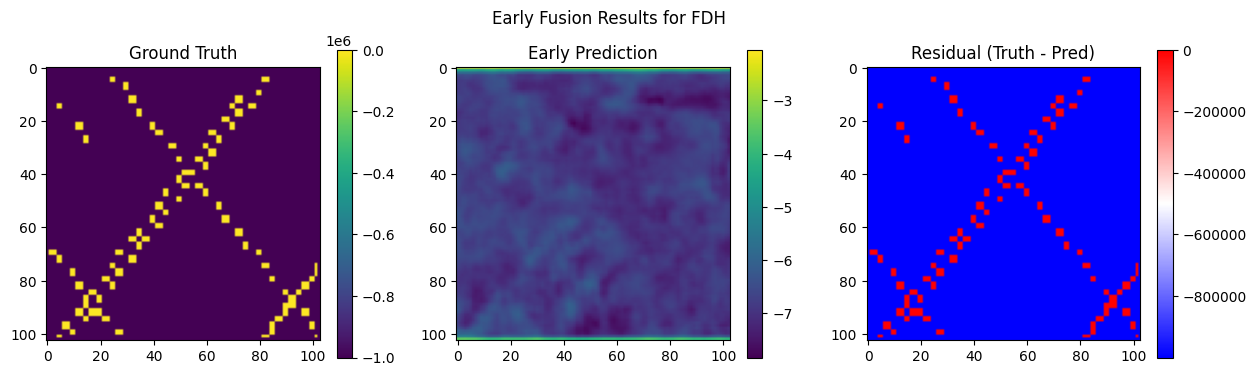

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step

----- Mid Fusion Evaluation -----
Mid MSE: 950935093248.0000
Mid RMSE: 975159.0092
Mid MAE: 950961.4375
Mid R²: -19.4008


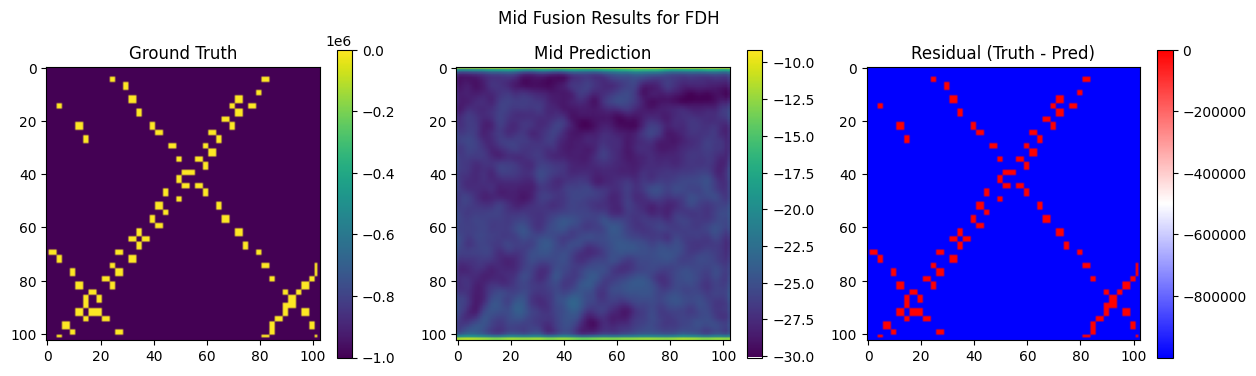

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

----- Late Fusion Evaluation -----
Late MSE: 950974545920.0000
Late RMSE: 975179.2378
Late MAE: 950980.0625
Late R²: -19.4016


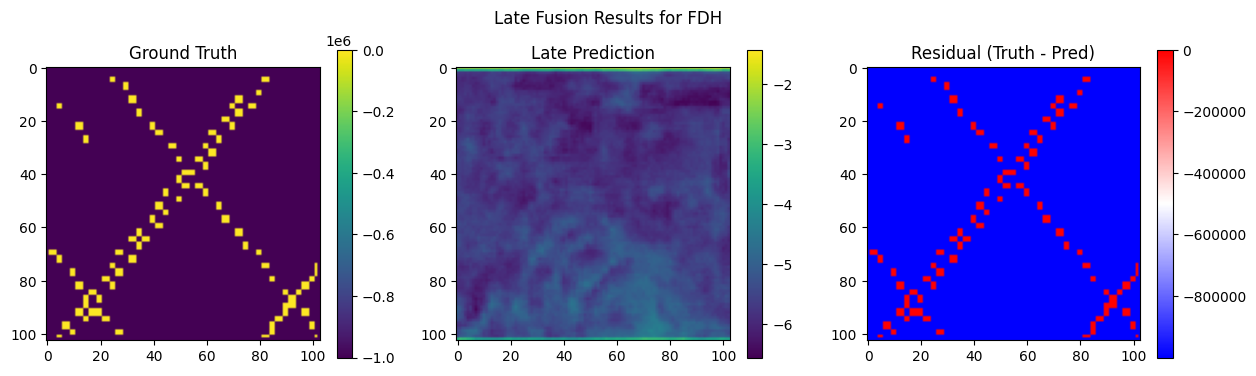

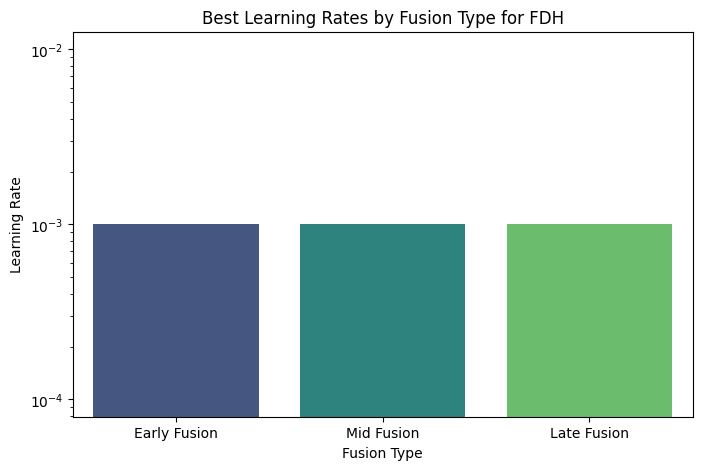


########## Running for target: Ht ##########

Early Fusion: filters=32, kernel=(3, 3), dropout=0.0, lr=0.001
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 611ms/step
Early Fusion: filters=32, kernel=(3, 3), dropout=0.0, lr=0.0001
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 714ms/step
Early Fusion: filters=32, kernel=(3, 3), dropout=0.2, lr=0.001
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 455ms/step
Early Fusion: filters=32, kernel=(3, 3), dropout=0.2, lr=0.0001
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 479ms/step
Early Fusion: filters=64, kernel=(3, 3), dropout=0.0, lr=0.001
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step
Early Fusion: filters=64, kernel=(3, 3), dropout=0.0, lr=0.0001
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step
Early Fusion: filters=64, kernel=(3, 3), dropout=0.2, lr=0.001
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
Early Fusion: filters=64, kernel=(3, 3), dropout=0.2, lr=0.0001
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step
Mid Fusion: filters=32, kernel=(3, 3), dropout=0.0, lr=0.001
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step
Mid Fusion: filters=32, kernel=(3, 3), dropout=

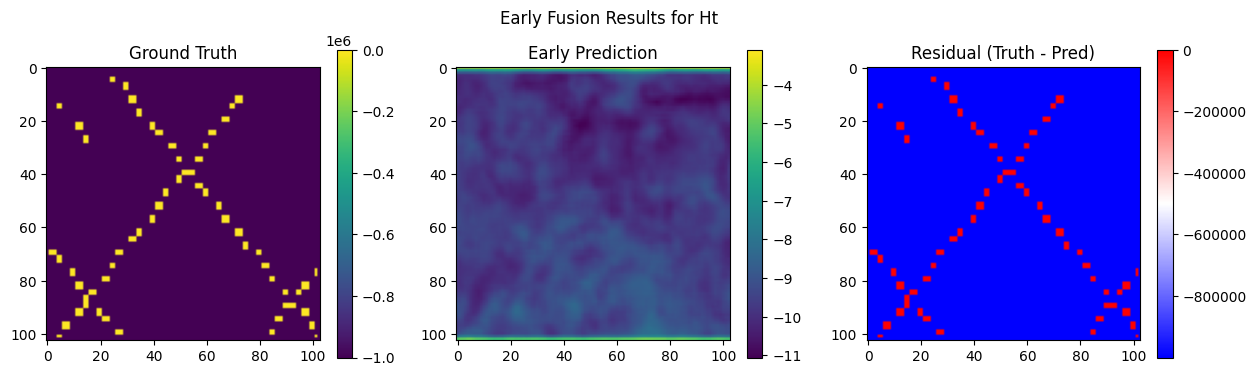

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step

----- Mid Fusion Evaluation -----
Mid MSE: 966113296384.0000
Mid RMSE: 982910.6248
Mid MAE: 966138.1875
Mid R²: -28.5496


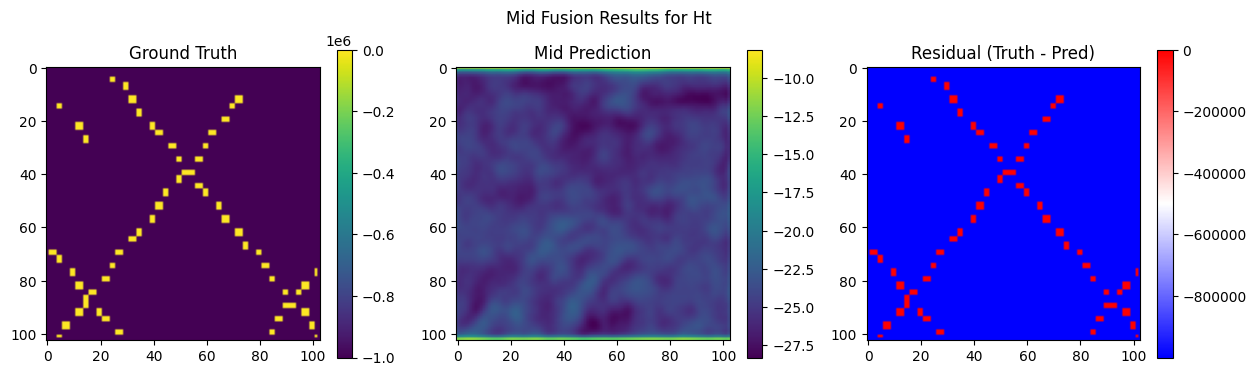

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step

----- Late Fusion Evaluation -----
Late MSE: 966151831552.0000
Late RMSE: 982930.2272
Late MAE: 966156.6875
Late R²: -28.5508


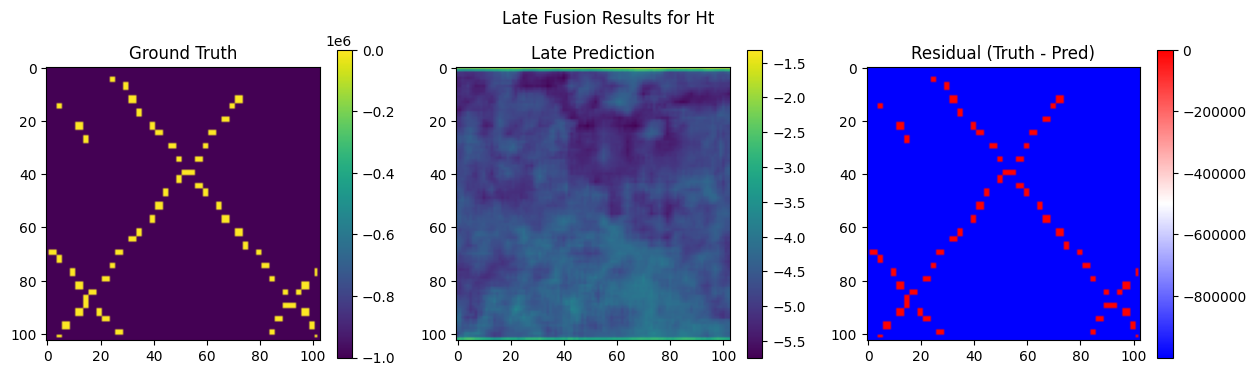

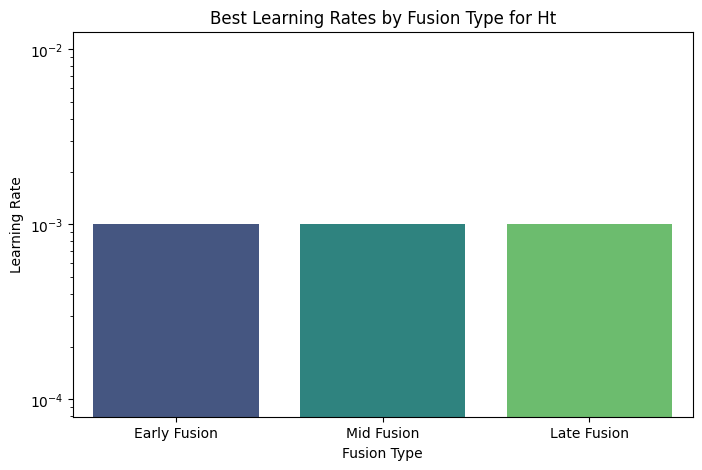


########## Running for target: PAI ##########

Early Fusion: filters=32, kernel=(3, 3), dropout=0.0, lr=0.001
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 487ms/step
Early Fusion: filters=32, kernel=(3, 3), dropout=0.0, lr=0.0001
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 479ms/step
Early Fusion: filters=32, kernel=(3, 3), dropout=0.2, lr=0.001
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 493ms/step
Early Fusion: filters=32, kernel=(3, 3), dropout=0.2, lr=0.0001
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 475ms/step
Early Fusion: filters=64, kernel=(3, 3), dropout=0.0, lr=0.001
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step
Early Fusion: filters=64, kernel=(3, 3), dropout=0.0, lr=0.0001
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step
Early Fusion: filters=64, kernel=(3, 3), dropout=0.2, lr=0.001
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
Early Fusion: filters=64, kernel=(3, 3), dropout=0.2, lr=0.0001
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step
Mid Fusion: filters=32, kernel=(3, 3), dropout=0.0, lr=0.001
4/4 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step
Mid Fusion: filters=32, kernel=(3, 3), dropout

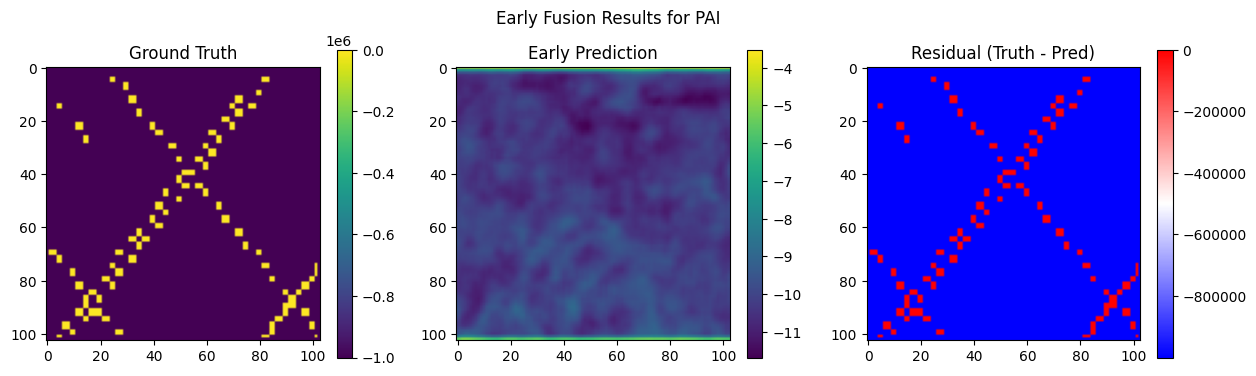

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step

----- Mid Fusion Evaluation -----
Mid MSE: 950954819584.0000
Mid RMSE: 975169.1236
Mid MAE: 950970.8125
Mid R²: -19.4012


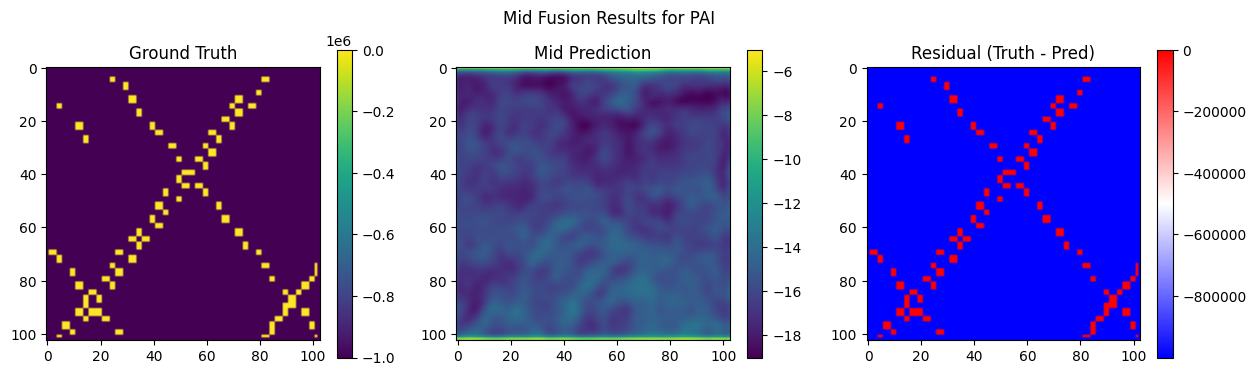

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step

----- Late Fusion Evaluation -----
Late MSE: 950975987712.0000
Late RMSE: 975179.9771
Late MAE: 950980.7500
Late R²: -19.4017


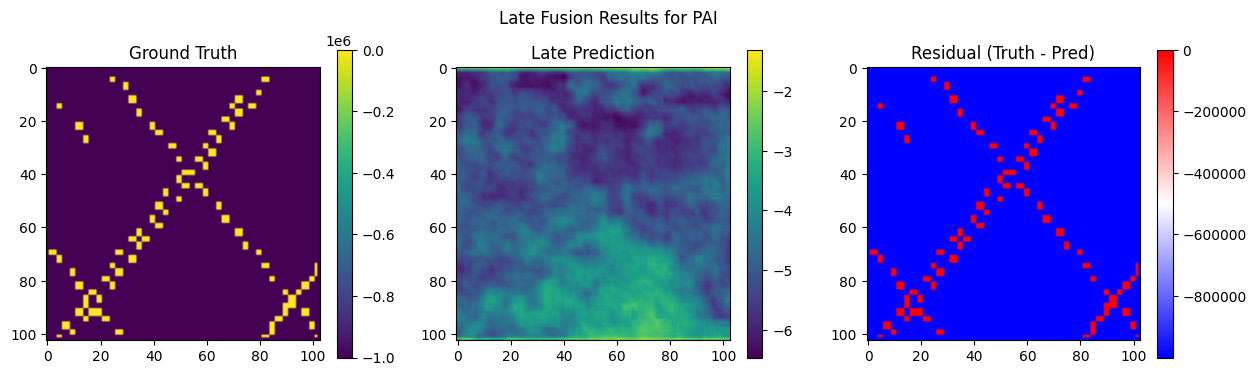

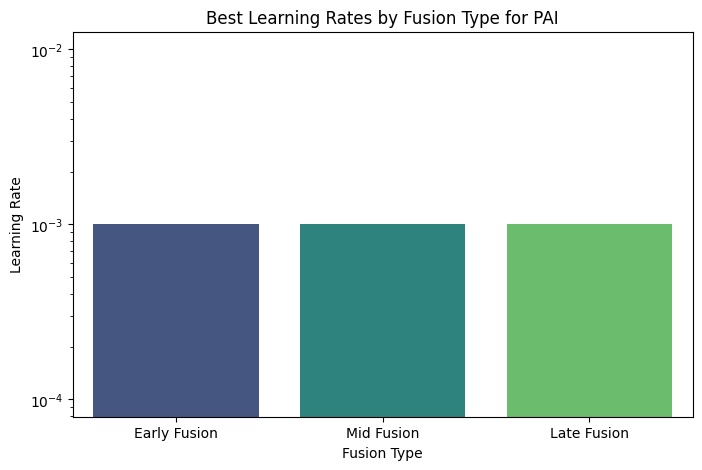

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow.keras.optimizers import Adam

# --- Hyperparameter grids ---
early_param_grid = {
    'model_params': [{'input_shape': (103, 107, 45)}],
    'filters': [32, 64],
    'kernel_size': [(3, 3)],
    'dropout_rate': [0.0, 0.2],
    'learning_rate': [1e-3, 1e-4]
}
mid_late_param_grid = {
    'model_params': [{}],
    'filters': [32, 64],
    'kernel_size': [(3, 3)],
    'dropout_rate': [0.0, 0.2],
    'learning_rate': [1e-3, 1e-4]
}

# --- Utility: Clean data ---
def clean_data(X, y):
    def clean_array(arr):
        arr = np.nan_to_num(arr, nan=0.0, posinf=1e6, neginf=-1e6)
        arr = np.clip(arr, -1e6, 1e6)
        return arr

    if isinstance(X, list):
        X = [clean_array(x) for x in X]
    else:
        X = clean_array(X)
    y = clean_array(y)
    return X, y

# --- Grid search ---
def hyperparameter_grid_search(build_fn, X, y, param_grid, fusion_type):
    results = []
    best_model, best_params, best_mse = None, None, float('inf')

    X, y = clean_data(X, y)

    if isinstance(X, list):
        X = [np.repeat(x, y.shape[0], axis=0) if x.shape[0] == 1 else x for x in X]
    else:
        if X.shape[0] == 1:
            X = np.repeat(X, y.shape[0], axis=0)

    if y.ndim == 2:
        y = np.expand_dims(y, axis=-1)
    if y.ndim == 3:
        y = np.expand_dims(y, axis=0)
    if y.shape[0] == 1:
        y = np.repeat(y, X[0].shape[0] if isinstance(X, list) else X.shape[0], axis=0)

    for model_params in param_grid['model_params']:
        for filters in param_grid['filters']:
            for kernel_size in param_grid['kernel_size']:
                for dropout_rate in param_grid['dropout_rate']:
                    for lr in param_grid['learning_rate']:
                        print(f"{fusion_type}: filters={filters}, kernel={kernel_size}, dropout={dropout_rate}, lr={lr}")

                        model = build_fn(filters=filters, kernel_size=kernel_size, dropout_rate=dropout_rate, **model_params)
                        model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
                        model.fit(X, y, epochs=1, verbose=0)
                        y_pred = model.predict(X)

                        mse = mean_squared_error(y.flatten(), y_pred.flatten())
                        rmse = np.sqrt(mse)
                        mae = mean_absolute_error(y.flatten(), y_pred.flatten())
                        r2 = r2_score(y.flatten(), y_pred.flatten())

                        results.append({
                            'fusion_type': fusion_type,
                            'filters': filters,
                            'kernel_size': str(kernel_size),
                            'dropout_rate': dropout_rate,
                            'learning_rate': lr,
                            'mse': mse,
                            'rmse': rmse,
                            'mae': mae,
                            'r2': r2
                        })

                        if mse < best_mse:
                            best_mse = mse
                            best_model = model
                            best_params = {
                                'filters': filters,
                                'kernel_size': kernel_size,
                                'dropout_rate': dropout_rate,
                                'learning_rate': lr,
                                **model_params
                            }

    return best_model, best_params, pd.DataFrame(results)

# --- Run grid search for multiple targets ---
targets = ['FDH', 'Ht', 'PAI']
y_train_dict = {'FDH': y_train_FDH, 'Ht': y_train_Ht, 'PAI': y_train_PAI}
y_test_dict = {'FDH': y_test_FDH, 'Ht': y_test_Ht, 'PAI': y_test_PAI}
y_val_dict = {'FDH': y_val_FDH, 'Ht': y_val_Ht, 'PAI': y_val_PAI}

for target in targets:
    print(f"\n########## Running for target: {target} ##########\n")
    y_train = y_train_dict[target]
    y_test = y_test_dict[target]
    y_val = y_val_dict[target]

    all_results = pd.DataFrame()

    # Early Fusion
    best_early_model, best_early_params, early_results = hyperparameter_grid_search(
        build_early_fusion, X_train, y_train, early_param_grid, 'Early Fusion')
    all_results = pd.concat([all_results, early_results], ignore_index=True)

    SAR_train, dem_train, landsat_train, sentinel_train = split_inputs(X_train)
    best_mid_model, best_mid_params, mid_results = hyperparameter_grid_search(
        build_mid_fusion, [SAR_train, dem_train, landsat_train, sentinel_train], y_train, mid_late_param_grid, 'Mid Fusion')
    all_results = pd.concat([all_results, mid_results], ignore_index=True)

    best_late_model, best_late_params, late_results = hyperparameter_grid_search(
        build_late_fusion, [SAR_train, dem_train, landsat_train, sentinel_train], y_train, mid_late_param_grid, 'Late Fusion')
    all_results = pd.concat([all_results, late_results], ignore_index=True)

    # --- Visualization ---
    def visualize_predictions(model, X_input, y_true, name):
        X_input, y_true = clean_data(X_input, y_true)
        y_pred = model.predict(X_input)

        y_true_flat = y_true.flatten()
        y_pred_flat = y_pred.flatten()

        mse = mean_squared_error(y_true_flat, y_pred_flat)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true_flat, y_pred_flat)
        r2 = r2_score(y_true_flat, y_pred_flat)

        print(f"\n----- {name} Fusion Evaluation -----")
        print(f"{name} MSE: {mse:.4f}")
        print(f"{name} RMSE: {rmse:.4f}")
        print(f"{name} MAE: {mae:.4f}")
        print(f"{name} R²: {r2:.4f}")

        plt.figure(figsize=(15, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(y_true[0, :, :, 0], cmap='viridis')
        plt.title('Ground Truth')
        plt.colorbar()

        plt.subplot(1, 3, 2)
        plt.imshow(y_pred[0, :, :, 0], cmap='viridis')
        plt.title(f'{name} Prediction')
        plt.colorbar()

        plt.subplot(1, 3, 3)
        plt.imshow((y_true[0, :, :, 0] - y_pred[0, :, :, 0]), cmap='bwr')
        plt.title('Residual (Truth - Pred)')
        plt.colorbar()

        plt.suptitle(f'{name} Fusion Results for {target}')
        plt.show()

    if y_test.ndim == 2:
        y_test = np.expand_dims(y_test, axis=-1)
    if y_test.ndim == 3:
        y_test = np.expand_dims(y_test, axis=0)
    if y_test.shape[0] == 1:
        y_test = np.repeat(y_test, X_test.shape[0], axis=0)

    visualize_predictions(best_early_model, X_test, y_test, 'Early')
    SAR_test, DEM_test, Landsat_test, Sentinel_test = split_inputs(X_test)
    visualize_predictions(best_mid_model, [SAR_test, DEM_test, Landsat_test, Sentinel_test], y_test, 'Mid')
    visualize_predictions(best_late_model, [SAR_test, DEM_test, Landsat_test, Sentinel_test], y_test, 'Late')

    # --- Extended analytics ---
    all_results['kernel_size_num'] = all_results['kernel_size'].apply(lambda x: int(str(x).strip('()').split(',')[0]))

    best_learning_rates = {
        'Early Fusion': best_early_params['learning_rate'],
        'Mid Fusion': best_mid_params['learning_rate'],
        'Late Fusion': best_late_params['learning_rate']
    }

    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(best_learning_rates.keys()), y=list(best_learning_rates.values()), palette='viridis')
    plt.title(f'Best Learning Rates by Fusion Type for {target}')
    plt.ylabel('Learning Rate')
    plt.xlabel('Fusion Type')
    plt.yscale('log')
    plt.show()


dev  -- under devleopment

In [18]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np
# import pandas as pd
# from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# from tensorflow.keras.optimizers import Adam

# # --- Hyperparameter grids ---
# early_param_grid = {
#     'model_params': [{'input_shape': (103, 107, 45)}],
#     'filters': [32, 64],
#     'kernel_size': [(3, 3)],
#     'dropout_rate': [0.0, 0.2],
#     'learning_rate': [1e-3, 1e-4]
# }
# mid_late_param_grid = {
#     'model_params': [{}],
#     'filters': [32, 64],
#     'kernel_size': [(3, 3)],
#     'dropout_rate': [0.0, 0.2],
#     'learning_rate': [1e-3, 1e-4]
# }

# # --- Grid search ---
# def hyperparameter_grid_search(build_fn, X, y, X_val, y_val, param_grid, fusion_type):
#     results = []
#     best_model, best_params, best_mse = None, None, float('inf')
#     best_history = None  # To store the history of the best model

#     for model_params in param_grid['model_params']:
#         for filters in param_grid['filters']:
#             for kernel_size in param_grid['kernel_size']:
#                 for dropout_rate in param_grid['dropout_rate']:
#                     for lr in param_grid['learning_rate']:
#                         print(f"{fusion_type}: filters={filters}, kernel={kernel_size}, dropout={dropout_rate}, lr={lr}")

#                         model = build_fn(filters=filters, kernel_size=kernel_size, dropout_rate=dropout_rate, **model_params)
#                         model.compile(optimizer=Adam(learning_rate=lr), loss='mse')

#                         # Ensure we pass the multiple inputs separately if the fusion model requires it
#                         if isinstance(X, list):  # Check if X contains a list of inputs
#                             history = model.fit(X, y, epochs=5, verbose=0, validation_data=(X_val, y_val))
#                         else:
#                             history = model.fit(X, y, epochs=5, verbose=0, validation_data=(X_val, y_val))

#                         y_pred = model.predict(X)

#                         mse = mean_squared_error(y.flatten(), y_pred.flatten())
#                         rmse = np.sqrt(mse)
#                         mae = mean_absolute_error(y.flatten(), y_pred.flatten())
#                         r2 = r2_score(y.flatten(), y_pred.flatten())

#                         results.append({
#                             'fusion_type': fusion_type,
#                             'filters': filters,
#                             'kernel_size': str(kernel_size),
#                             'dropout_rate': dropout_rate,
#                             'learning_rate': lr,
#                             'mse': mse,
#                             'rmse': rmse,
#                             'mae': mae,
#                             'r2': r2
#                         })

#                         if mse < best_mse:
#                             best_mse = mse
#                             best_model = model
#                             best_params = {
#                                 'filters': filters,
#                                 'kernel_size': kernel_size,
#                                 'dropout_rate': dropout_rate,
#                                 'learning_rate': lr,
#                                 **model_params
#                             }
#                             best_history = history  # Store the history of the best model

#     return best_model, best_params, pd.DataFrame(results), best_history


# # --- Run grid search ---
# all_results = pd.DataFrame()

# best_early_model, best_early_params, early_results, best_early_history = hyperparameter_grid_search(
#     build_early_fusion, X_train, y_train, X_test, y_test, early_param_grid, 'Early Fusion')
# all_results = pd.concat([all_results, early_results], ignore_index=True)

# SAR_train, dem_train, landsat_train, sentinel_train = split_inputs(X_train)
# best_mid_model, best_mid_params, mid_results, best_mid_history = hyperparameter_grid_search(
#     build_mid_fusion, [SAR_train, dem_train, landsat_train, sentinel_train], y_train, X_test, y_test, mid_late_param_grid, 'Mid Fusion')
# all_results = pd.concat([all_results, mid_results], ignore_index=True)

# best_late_model, best_late_params, late_results, best_late_history = hyperparameter_grid_search(
#     build_late_fusion, [SAR_train, dem_train, landsat_train, sentinel_train], y_train, X_test, y_test, mid_late_param_grid, 'Late Fusion')
# all_results = pd.concat([all_results, late_results], ignore_index=True)

# # --- Visualization of predictions ---
# def visualize_predictions(model, X_input, y_true, name):
#     print(f"\n----- {name} Fusion Evaluation -----")

#     y_pred = model.predict(X_input)

#     y_true_flat = y_true.flatten()
#     y_pred_flat = y_pred.flatten()

#     mse = mean_squared_error(y_true_flat, y_pred_flat)
#     r2 = r2_score(y_true_flat, y_pred_flat)
#     mae = mean_absolute_error(y_true_flat, y_pred_flat)
#     rmse = np.sqrt(mse)

#     print(f"{name} MSE: {mse:.4f}")
#     print(f"{name} RMSE: {rmse:.4f}")
#     print(f"{name} MAE: {mae:.4f}")
#     print(f"{name} R²: {r2:.4f}")

#     plt.figure(figsize=(15, 4))
#     plt.subplot(1, 3, 1)
#     plt.imshow(y_true[0, :, :, 0], cmap='viridis')
#     plt.title('Ground Truth')
#     plt.colorbar()

#     plt.subplot(1, 3, 2)
#     plt.imshow(y_pred[0, :, :, 0], cmap='viridis')
#     plt.title(f'{name} Prediction')
#     plt.colorbar()

#     plt.subplot(1, 3, 3)
#     plt.imshow((y_true[0, :, :, 0] - y_pred[0, :, :, 0]), cmap='bwr')
#     plt.title('Residual (Truth - Pred)')
#     plt.colorbar()

#     plt.suptitle(f'{name} Fusion Results')
#     plt.show()

# # --- Run visualizations ---
# visualize_predictions(best_early_model, X_test, y_test, 'Early')
# SAR_test, DEM_test, Landsat_test, Sentinel_test = split_inputs(X_test)
# visualize_predictions(best_mid_model, [SAR_test, DEM_test, Landsat_test, Sentinel_test], y_test, 'Mid')
# visualize_predictions(best_late_model, [SAR_test, DEM_test, Landsat_test, Sentinel_test], y_test, 'Late')

# # --- Extended analytics ---
# # Prepare numeric kernel size
# all_results['kernel_size_num'] = all_results['kernel_size'].apply(lambda x: int(str(x).strip('()').split(',')[0]))
# metrics_cols = ['mse', 'rmse', 'mae', 'r2']
# param_cols = ['filters', 'kernel_size_num', 'dropout_rate', 'learning_rate']

# # -------------------------------
# # Plot best learning rates for Early, Mid, Late
# # -------------------------------
# best_learning_rates = {
#     'Early Fusion': best_early_params['learning_rate'],
#     'Mid Fusion': best_mid_params['learning_rate'],
#     'Late Fusion': best_late_params['learning_rate']
# }

# plt.figure(figsize=(8, 5))
# sns.barplot(x=list(best_learning_rates.keys()), y=list(best_learning_rates.values()), palette='viridis')
# plt.title('Best Learning Rates by Fusion Type')
# plt.ylabel('Learning Rate')
# plt.xlabel('Fusion Type')
# plt.yscale('log')  # use log scale since learning rates are usually small
# plt.show()

# # -------------------------------
# # Plot training and validation loss for the best models
# # -------------------------------

# # Plotting Early Fusion Loss
# plt.figure(figsize=(10, 6))
# plt.plot(best_early_history.history['loss'], label='Train Loss')
# plt.plot(best_early_history.history['val_loss'], label='Validation Loss')
# plt.title('Early Fusion Loss Over Epochs')
# plt.xlabel('Epoch')
# plt.ylabel('Loss (MSE)')
# plt.legend()
# plt.show()

# # Plotting Mid Fusion Loss
# plt.figure(figsize=(10, 6))
# plt.plot(best_mid_history.history['loss'], label='Train Loss')
# plt.plot(best_mid_history.history['val_loss'], label='Validation Loss')
# plt.title('Mid Fusion Loss Over Epochs')
# plt.xlabel('Epoch')
# plt.ylabel('Loss (MSE)')
# plt.legend()
# plt.show()

# # Plotting Late Fusion Loss
# plt.figure(figsize=(10, 6))
# plt.plot(best_late_history.history['loss'], label='Train Loss')
# plt.plot(best_late_history.history['val_loss'], label='Validation Loss')
# plt.title('Late Fusion Loss Over Epochs')
# plt.xlabel('Epoch')
# plt.ylabel('Loss (MSE)')
# plt.legend()
# plt.show()


Block 2.5 Break point if needed run the model with out hyperparamater tuning (intened to be used once the modle is tuned and params are known)

In [19]:


# def compile_and_train_with_validation(model, X_train, y_train, X_val, y_val, name):
#     model.compile(optimizer=Adam(), loss='mse')
#     history = model.fit(
#         X_train, y_train,
#         validation_data=(X_val, y_val),
#         epochs=10,
#         verbose=1
#     )
#     y_pred = model.predict(X_train)

#     mse = mean_squared_error(y_train.flatten(), y_pred.flatten())
#     r2 = r2_score(y_train.flatten(), y_pred.flatten())
#     print(f"{name}-fusion MSE (train): {mse:.4f}, R^2 (train): {r2:.4f}")

#     # Plot training vs validation loss over epochs
#     plt.figure(figsize=(8, 5))
#     plt.plot(history.history['loss'], label='Train Loss')
#     plt.plot(history.history['val_loss'], label='Validation Loss')
#     plt.title(f'{name}-Fusion Loss Over Epochs')
#     plt.xlabel('Epoch')
#     plt.ylabel('Loss (MSE)')
#     plt.legend()
#     plt.show()

#     # # Optional: show first prediction visually
#     # plt.imshow(y_pred[0, :, :, 0], cmap='viridis')
#     # plt.title(f'{name}-Fusion Prediction (Sample)')
#     # plt.colorbar()
#     # plt.show()


# # Early Fusion
# compile_and_train_with_validation(best_early_model, X_train, y_train, X_test, y_test, 'Early')

# # Mid Fusion
# SAR_train, dem_train, landsat_train, sentinel_train = split_inputs(X_train)
# SAR_test, DEM_test, Landsat_test, Sentinel_test = split_inputs(X_test)
# compile_and_train_with_validation(
#     best_mid_model,
#     [SAR_train, dem_train, landsat_train, sentinel_train],
#     y_train,
#     [SAR_test, DEM_test, Landsat_test, Sentinel_test],
#     y_test,
#     'Mid'
# )

# # Late Fusion
# compile_and_train_with_validation(
#     best_late_model,
#     [SAR_train, dem_train, landsat_train, sentinel_train],
#     y_train,
#     [SAR_test, DEM_test, Landsat_test, Sentinel_test],
#     y_test,
#     'Late'
# )


# Block 3: Save Results + Plot + Visualize Best Model

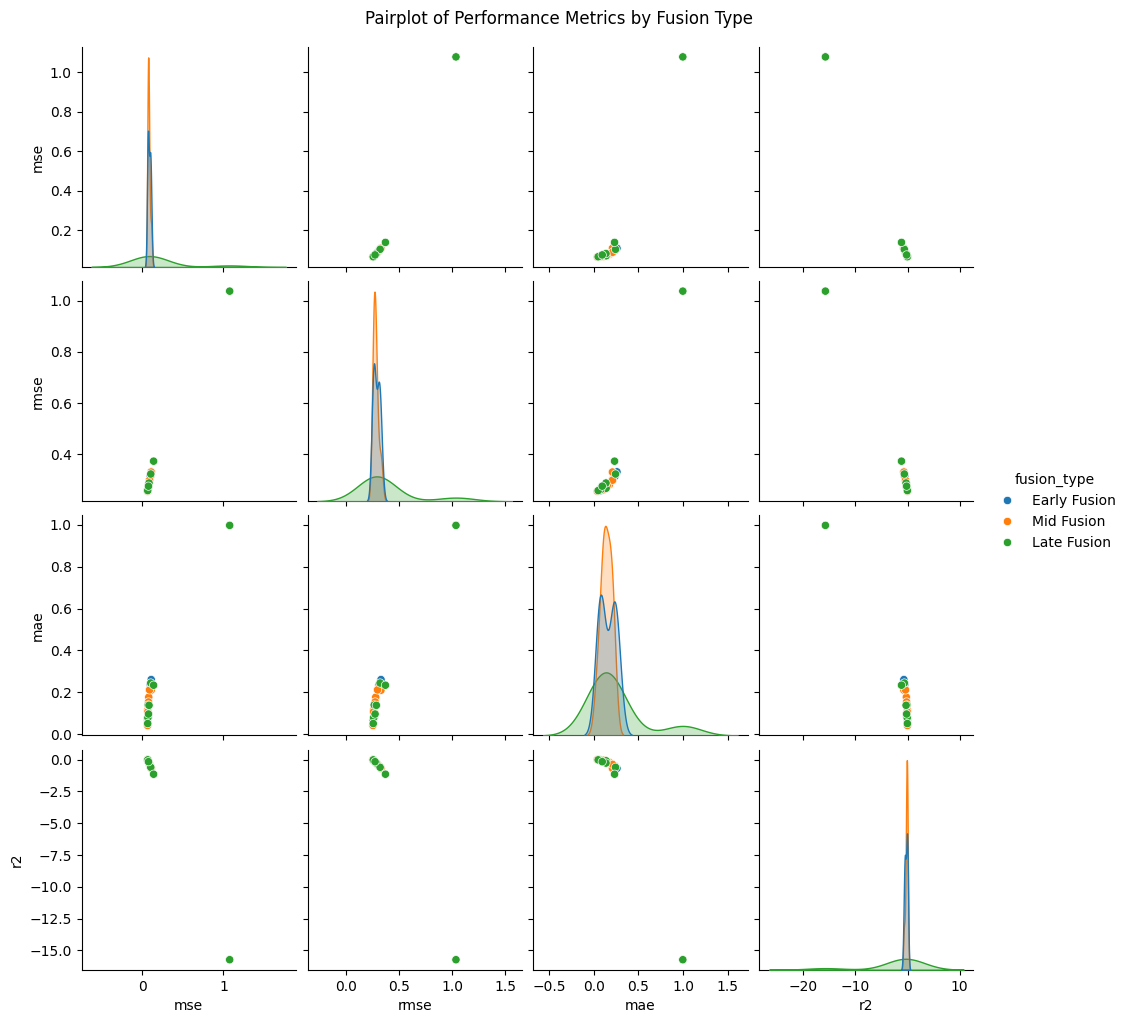

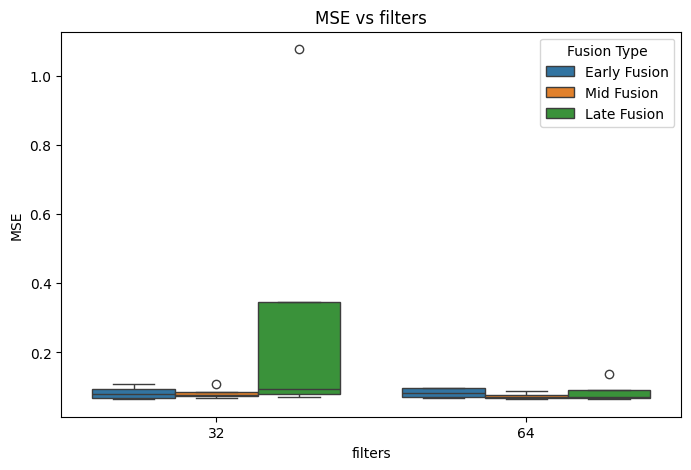

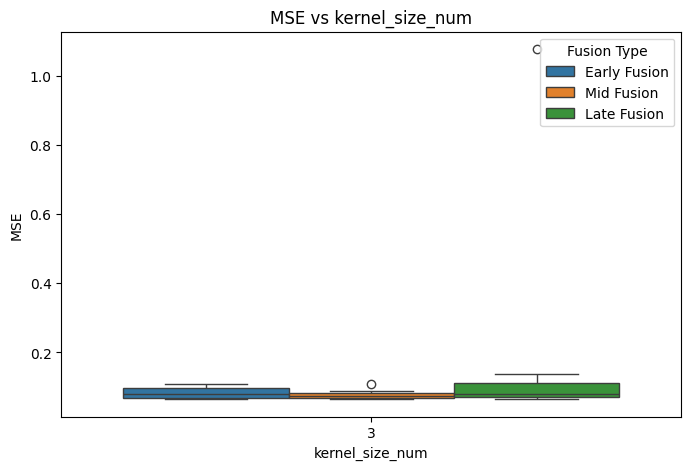

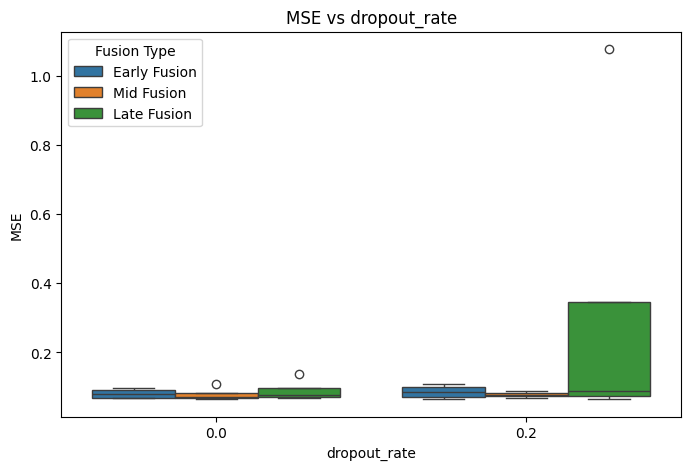

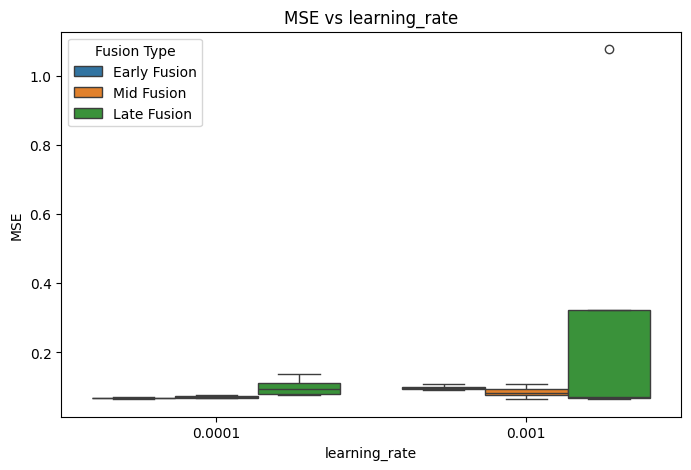

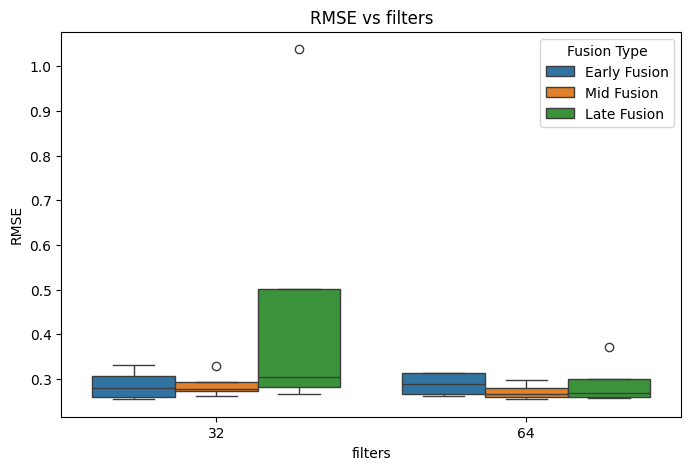

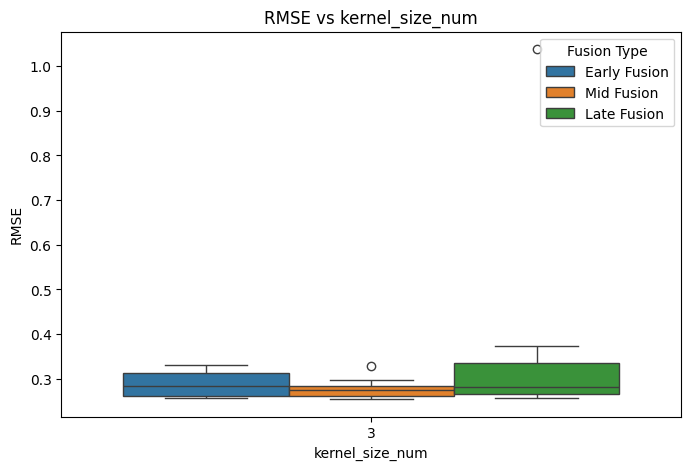

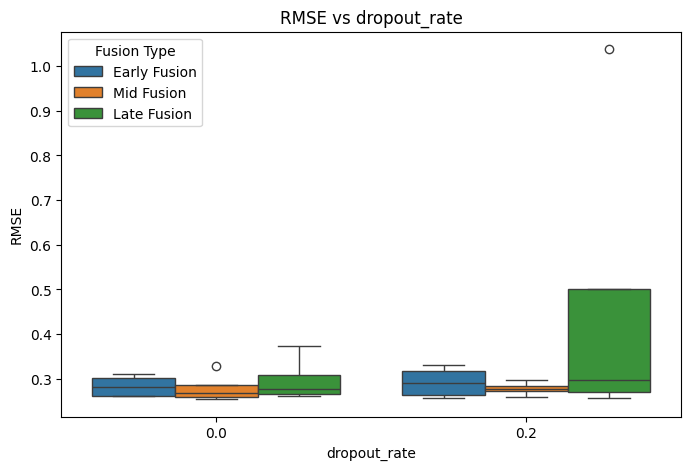

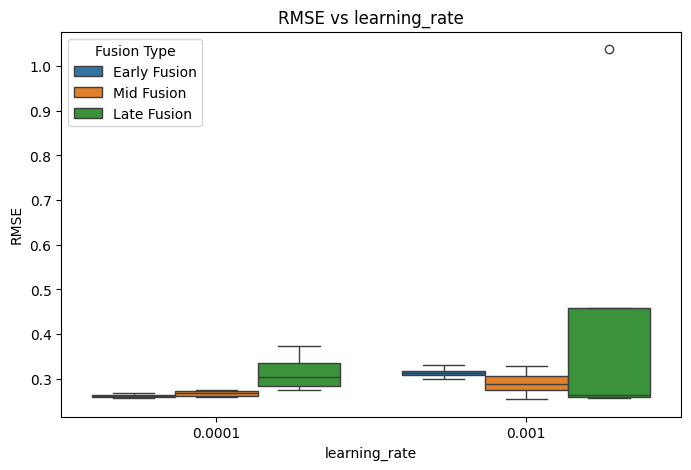

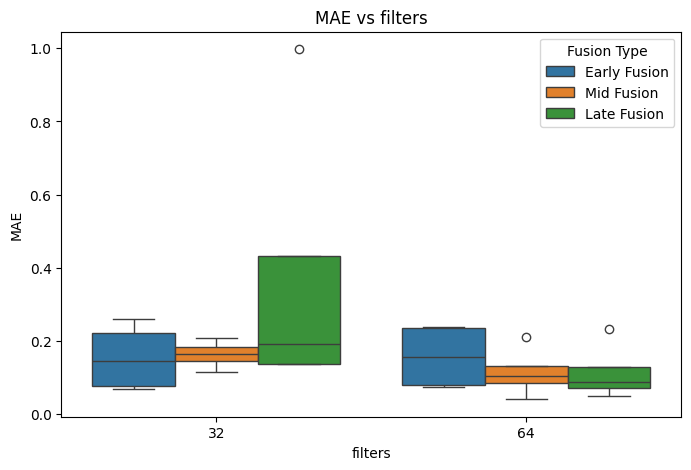

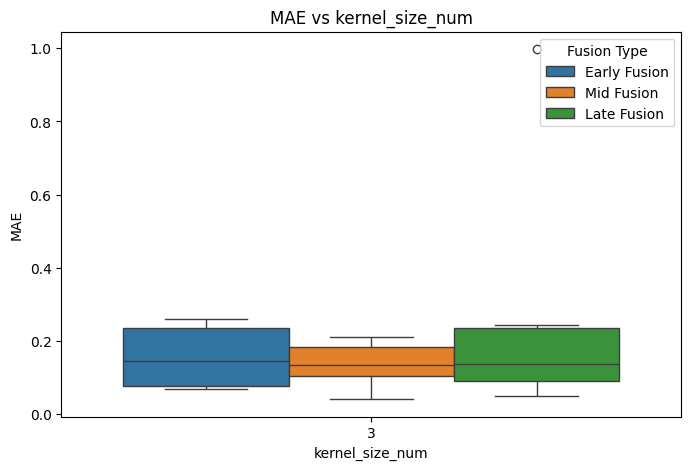

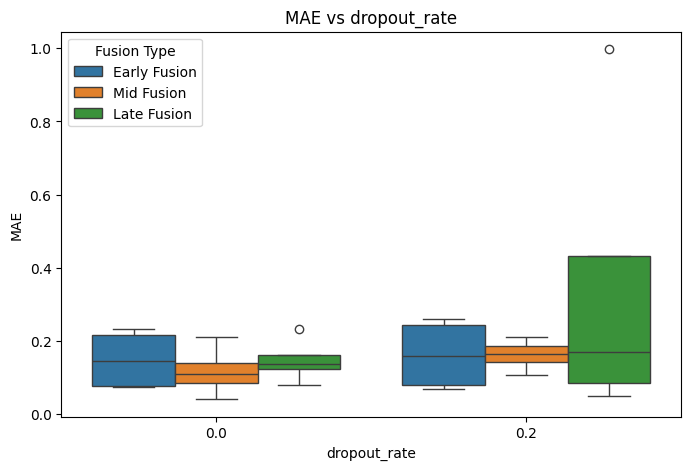

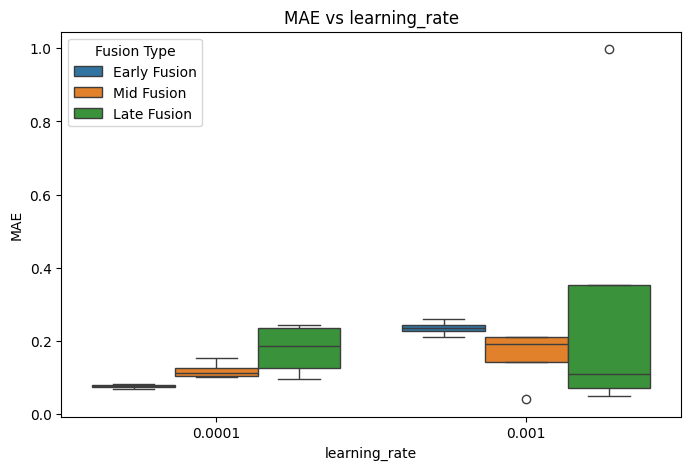

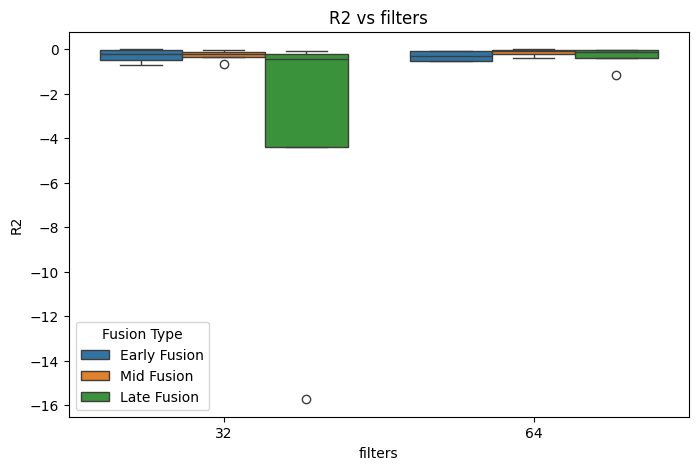

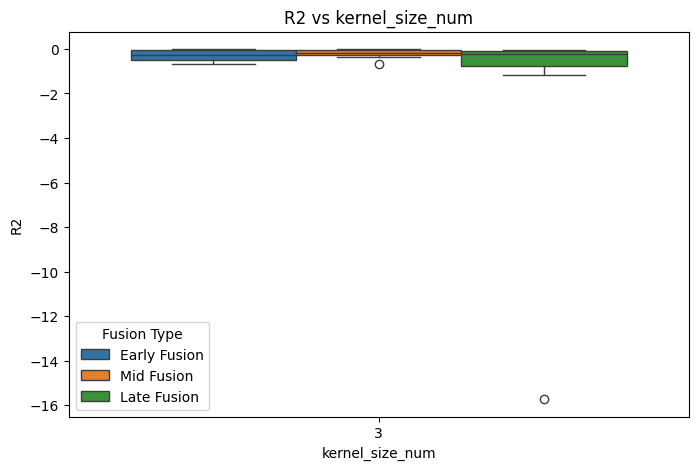

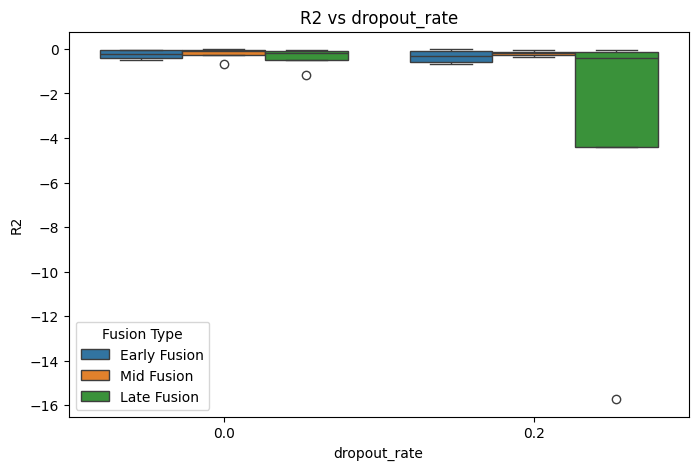

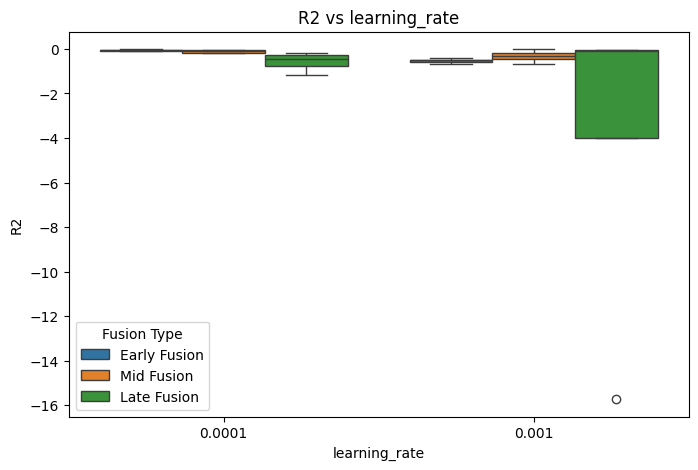

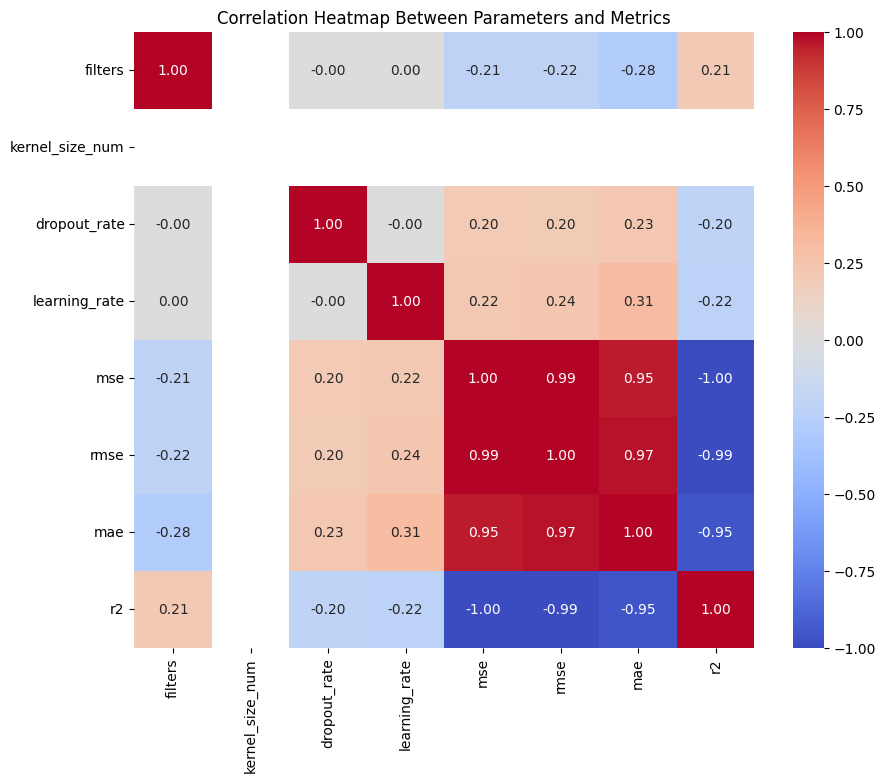

Best Early Fusion Params: {'filters': 64, 'kernel_size': (3, 3), 'dropout_rate': 0.0, 'learning_rate': 0.001, 'input_shape': (103, 107, 45)}
Best Mid Fusion Params: {'filters': 64, 'kernel_size': (3, 3), 'dropout_rate': 0.2, 'learning_rate': 0.001}
Best Late Fusion Params: {'filters': 64, 'kernel_size': (3, 3), 'dropout_rate': 0.0, 'learning_rate': 0.001}
best_late_model.summary()


Model: "functional_52"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_148 (InputLayer)    │ (None, 103, 107, 45)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_364 (Conv2D)             │ (None, 103, 107, 64)   │        25,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_148 (Dropout)           │ (None, 103, 107, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_365 (Conv2D)             │ (None, 103, 107, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d_100 (Cropping2D)     │ (None, 103, 103, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_366 (Conv2D)             │ (None, 103, 103, 1)    │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 299,909 (1.14 MB)

 Trainable params: 99,969 (390.50 KB)

...

 Total params: 79,316 (309.83 KB)

 Trainable params: 26,438 (103.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 52,878 (206.56 KB)

complete


In [20]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# --- Load results (if not already in memory) ---
all_results = pd.read_csv("hyperparameter_results.csv")

# --- Convert kernel_size (tuple) to just one numeric value (e.g., first element) ---
if 'kernel_size' in all_results.columns:
    all_results['kernel_size_num'] = all_results['kernel_size'].apply(lambda x: int(str(x).strip('()').split(',')[0]))

# --- Seaborn pairplot for metrics ---
metrics_cols = ['mse', 'rmse', 'mae', 'r2']
sns.pairplot(all_results, vars=metrics_cols, hue='fusion_type')
plt.suptitle("Pairplot of Performance Metrics by Fusion Type", y=1.02)
plt.show()

# --- Compare metrics vs model parameters ---
param_cols = ['filters', 'kernel_size_num', 'dropout_rate', 'learning_rate']
for metric in metrics_cols:
    for param in param_cols:
        if param in all_results.columns:
            plt.figure(figsize=(8, 5))
            sns.boxplot(x=param, y=metric, hue='fusion_type', data=all_results)
            plt.title(f'{metric.upper()} vs {param}')
            plt.xlabel(param)
            plt.ylabel(metric.upper())
            plt.legend(title='Fusion Type')
            plt.show()

# --- Correlation heatmap between parameters and metrics ---
corr_cols = [col for col in param_cols if col in all_results.columns] + metrics_cols
corr_matrix = all_results[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap Between Parameters and Metrics')
plt.show()

# --- Print best models ---
print("Best Early Fusion Params:", best_early_params)
print("Best Mid Fusion Params:", best_mid_params)
print("Best Late Fusion Params:", best_late_params)

# --- Visualize best model architecture ---
print("best_late_model.summary()")
best_early_model.summary()
best_early_model.save('best_early_model.h5')

print("best_mid_model.summary()")
best_mid_model.summary()
best_mid_model.save('best_mid_model.h5')

print("best_late_model.summary()")
best_late_model.summary()
best_late_model.save('best_late_model.h5')

print("complete")


In [21]:
# STEP 1: Install dependencies
!apt-get update
!apt-get install texlive-latex-base texlive-fonts-recommended texlive-fonts-extra texlive-latex-extra dvipng cm-super imagemagick -y

# # STEP 2: Clone PlotNeuralNet repo
# !git clone https://github.com/HarisIqbal88/PlotNeuralNet.git

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,722 kB]
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [2,901 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,932

In [61]:
# %rm -r /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/model_architecture_images/*

This does work, but makes tree level figures

In [51]:
import os
import subprocess

# --- Paths ---
tex_gen_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/PlotNeuralNet/pyexamples/latex_generate.py'
output_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/model_architecture_images'
base_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/PlotNeuralNet'

# --- Helper to write tex description ---
def write_tex_file(model_name, model):
    from tensorflow.keras.utils import plot_model
    plot_path = os.path.join(base_path, f"{model_name}.png")
    plot_model(model, to_file=plot_path, show_shapes=True)
    return plot_path

# --- Generate LaTeX architecture image ---
def generate_plot_neural_net(model_name, model):
    tex_file_path = write_tex_file(model_name, model)

    # You must have LaTeX and ImageMagick installed in the colab/session
    os.chdir(base_path)
    tex_src = f"{model_name}.tex"

    # Build a dummy tex file from a prewritten template or manually build it
    with open(tex_src, 'w') as f:
        f.write(r"""
\documentclass[border=8pt]{standalone}
\usepackage{import}
\subimport{./}{preamble.tex}
\begin{document}
\input{examples/""" + model_name + r"""}
\end{document}
""")

    # Compile LaTeX to PDF
    subprocess.run(['pdflatex', tex_src], stdout=subprocess.PIPE)

    # Convert PDF to JPG
    pdf_path = os.path.join(base_path, f"{model_name}.pdf")
    jpg_path = os.path.join(output_dir, f"{model_name}.jpg")
    subprocess.run(['convert', '-density', '300', pdf_path, '-quality', '90', jpg_path])

    print(f"Saved {model_name} architecture visualization at {jpg_path}")

# --- Create visualizations ---
generate_plot_neural_net("early_fusion_model", best_early_model)
generate_plot_neural_net("mid_fusion_model", best_mid_model)
generate_plot_neural_net("late_fusion_model", best_late_model)


Saved early_fusion_model architecture visualization at /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/model_architecture_images/early_fusion_model.jpg
Saved mid_fusion_model architecture visualization at /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/model_architecture_images/mid_fusion_model.jpg
Saved late_fusion_model architecture visualization at /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/model_architecture_images/late_fusion_model.jpg


xxxxxxxxxxxxxxxxx

In [74]:
# %rm -r /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/PlotNeuralNet/*

In [ ]:
# %rm -r /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/model_architecture_images/*

#Block 4 Reproject and export predicitons

In [ ]:
import tifffile as tiff
import os

# Create output directory if it doesn't exist
# directory_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/fusion_predictions_tifs"
# os.mkdir(directory_path)

output_dir = 'fusion_predictions_tifs'
os.makedirs(output_dir, exist_ok=True)

# Generate predictions
early_pred = best_early_model.predict(X_test)
mid_pred = best_mid_model.predict([SAR_test, DEM_test, Landsat_test, Sentinel_test])
late_pred = best_late_model.predict([SAR_test, DEM_test, Landsat_test, Sentinel_test])

# Save as TIFF files (only first sample, or loop if you want all)
tiff.imwrite(os.path.join(output_dir, 'early_fusion_prediction.tif'), early_pred[0, :, :, 0])
tiff.imwrite(os.path.join(output_dir, 'mid_fusion_prediction.tif'), mid_pred[0, :, :, 0])
tiff.imwrite(os.path.join(output_dir, 'late_fusion_prediction.tif'), late_pred[0, :, :, 0])

print(f"TIFF files saved in folder: {output_dir}")


Usign GEE orginal image as reference

In [ ]:
import ee
import geemap
import numpy as np
import rasterio
from rasterio.transform import from_origin
import os
import glob

# # Initialize Earth Engine
# ee.Initialize()

# Load the reference GEE image
reference_image = ee.Image("projects/servir-sco-assets/assets/PR/s1Ascending_2022")

# Get projection details from the reference image
proj = reference_image.projection()
crs = proj.crs().getInfo()
scale = proj.nominalScale().getInfo()

# Get the bounds (region) from the reference image
bounds = reference_image.geometry().bounds().coordinates().getInfo()[0]

# Extract upper-left corner and calculate width/height in degrees
ulx = min([pt[0] for pt in bounds])
lrx = max([pt[0] for pt in bounds])
uly = max([pt[1] for pt in bounds])
lry = min([pt[1] for pt in bounds])

# Calculate pixel size in degrees
width = 103
height = 103
xres = (lrx - ulx) / width
yres = (uly - lry) / height

# Prepare the transform
transform = from_origin(ulx, uly, abs(xres), abs(yres))

# Define input and output directories
input_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/fusion_predictions_tifs'
output_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/Reprojected_predictions'

# Make sure the output directory exists
os.makedirs(output_dir, exist_ok=True)

# Find all .tif files in the input directory
tif_files = glob.glob(os.path.join(input_dir, '*.tif'))

# Process each TIFF file
for tif_file in tif_files:
    # Load the predicted array
    with rasterio.open(tif_file) as src:
        data = src.read(1)  # assuming single-band
        # Optionally, squeeze if you expect shape (1, 1, 103, 103, 1)
        data = np.squeeze(data)

    # Check dimensions, resample if needed
    if data.shape != (103, 103):
        print(f"Warning: {os.path.basename(tif_file)} has shape {data.shape}, expected (103, 103). Skipping.")
        continue

    # Define output filename
    output_filename = os.path.basename(tif_file).replace('.tif', '_reproj.tif')
    output_path = os.path.join(output_dir, output_filename)

    # Write the GeoTIFF
    with rasterio.open(
        output_path,
        'w',
        driver='GTiff',
        height=height,
        width=width,
        count=1,  # single band
        dtype=data.dtype,
        crs=crs,
        transform=transform
    ) as dst:
        dst.write(data, 1)

    print(f"Saved reprojected file: {output_path}")

print("Batch processing completed.")


Back-up if you need to manually reporject the tiff

In [ ]:
# import numpy as np
# import rasterio
# from rasterio.transform import from_origin

# # Example input (your prediction array)
# array_2d = np.squeeze(early_pred)  # Shape becomes (103, 103)

# # Upper-left and lower-right coordinates (in degrees)
# ulx = -66.88492974621839
# uly = 17.968731133657553
# lrx = -66.87537229630139
# lry = 17.95952393838524

# # Grid size
# width = 103
# height = 103

# # Calculate pixel size in degrees
# xres = (lrx - ulx) / width
# yres = (lry - uly) / height  # negative for north-up rasters

# # Define transform (note: from_origin uses positive yres; we provide abs)
# transform = from_origin(ulx, uly, abs(xres), abs(yres))

# # Define output path
# output_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/Reprojected_predictions/early_fusion_prediction_reproj.tif'

# # Write the GeoTIFF
# with rasterio.open(
#     output_path,
#     'w',
#     driver='GTiff',
#     height=height,
#     width=width,
#     count=1,  # single band
#     dtype=array_2d.dtype,
#     crs='EPSG:4326',
#     transform=transform
# ) as dst:
#     dst.write(array_2d, 1)

# print(f"GeoTIFF saved to {output_path}")


# Block 5: Independant Valdiation with Neon

Access clean and use NEON Veg site data: working notebook: https://github.com/MayerT1/LiDAR_Dev/blob/main/Neon_tree_height_and_Lidar_CHM.ipynb

Laz fecth and viz: https://github.com/MayerT1/LiDAR_Dev/blob/main/NEON_Discrete_Lidar_Data.ipynb

In [26]:
import laspy
import numpy as np
import rasterio
from rasterio.transform import from_origin
from scipy.stats import entropy


In [27]:
import os
# use os.path.join to get the full path of the laz file
laz_data_file=os.path.join("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/NEON/",'NEON_D04_GUAN_DP1_724000_1987000_classified_point_cloud_colorized.laz')
# read the laz file into a LasData object using laspy.read()
point_cloud=laspy.read(laz_data_file)

In [ ]:
# import laspy
# import numpy as np
# import rasterio
# from rasterio.transform import from_origin
# from scipy.stats import entropy

# # Load LAZ file
# las = laspy.read("/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/NEON/NEON_D04_GUAN_DP1_724000_1987000_classified_point_cloud_colorized.laz")

# # Extract data
# x = las.x
# y = las.y
# z = las.z
# classification = las.classification

# # Identify ground points
# ground_z = z[classification == 2]

# # Build ground surface (simple min height per (x, y))
# from scipy.spatial import cKDTree

# ground_coords = np.vstack((x[classification == 2], y[classification == 2])).T
# tree = cKDTree(ground_coords)
# _, idx = tree.query(np.vstack((x, y)).T, k=1)
# ground_heights = z[classification == 2][idx]

# # Compute height above ground (HAG)
# hag = z - ground_heights

# # Define grid parameters
# resolution = 1  # meters
# xmin, ymin, xmax, ymax = x.min(), y.min(), x.max(), y.max()
# ncols = int(np.ceil((xmax - xmin) / resolution))
# nrows = int(np.ceil((ymax - ymin) / resolution))
# print("ncols", ncols)
# print("nrows", nrows)

# # Initialize diversity grid
# diversity_grid = np.full((nrows, ncols), np.nan)
# print("diversity_grid", diversity_grid)
# # Define height bins
# bins = [0, 5, 10, 15, 20, np.inf]

# # Assign points to grid cells
# col_idx = ((x - xmin) / resolution).astype(int)
# row_idx = ((ymax - y) / resolution).astype(int)  # flip Y axis

# # Loop through each grid cell
# for r in range(nrows):
#     for c in range(ncols):
#         mask = (row_idx == r) & (col_idx == c) & (hag > 0)
#         if np.sum(mask) > 0:
#             cell_heights = hag[mask]
#             hist, _ = np.histogram(cell_heights, bins=bins)
#             hist = hist[hist > 0]
#             print("hist", hist)
#             if len(hist) > 1:
#                 shannon = entropy(hist, base=2)
#                 diversity_grid[r, c] = shannon
#                 print("diversity_grid shannon:", diversity_grid)
#             else:
#                 diversity_grid[r, c] = 0  # no diversity if only one bin filled

# # Save as GeoTIFF
# transform = from_origin(xmin, ymax, resolution, resolution)
# with rasterio.open(
#     'foliage_height_diversity.tif',
#     'w',
#     driver='GTiff',
#     height=nrows,
#     width=ncols,
#     count=1,
#     dtype=diversity_grid.dtype,
#     crs=las.header.parse_crs().to_wkt(),
#     transform=transform,
# ) as dst:
#     dst.write(diversity_grid, 1)

# print("Saved foliage_height_diversity.tif")


Run this R code to make Laz to FD product
https://r-lidar.github.io/lidRbook/itd.html


https://r-lidar.github.io/lidRbook/grid_metrics.html

In [29]:
# activate R magic
%load_ext rpy2.ipython

Saved CHM raster to: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/NEON/lidar_metrics_outputs/canopy_height_model_lidr.tif 
Processed 999888 groups out of 999888. 100% done. Time elapsed: 4s. ETA: 0s.
Saved FHD raster to: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/NEON/lidar_metrics_outputs/foliage_height_diversity_lidr.tif 
Processed 999888 groups out of 999888. 100% done. Time elapsed: 3s. ETA: 0s.
Saved PAI raster to: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/NEON/lidar_metrics_outputs/plant_area_index_lidr.tif 


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘proxy’, ‘wk’, ‘e1071’, ‘s2’, ‘units’, ‘abind’, ‘classInt’, ‘lazyeval’, ‘rgl’, ‘rlas’, ‘sf’, ‘stars’, ‘terra’, ‘BH’, ‘RcppArmadillo’

trying URL 'https://cran.rstudio.com/src/contrib/proxy_0.4-27.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/wk_0.9.4.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/e1071_1.7-16.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/s2_1.1.8.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/units_0.8-7.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/abind_1.4-8.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/classInt_0.4-11.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/lazyeval_0.2.2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/rgl_1.3.18.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/rlas_1.8.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/sf_1.0-20.t

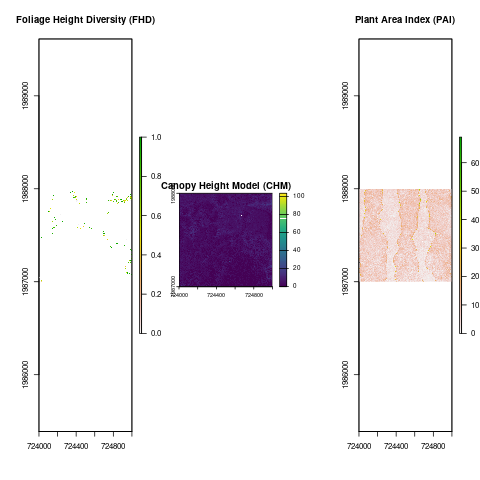

In [30]:
%%R

# Install required packages if missing
if (!requireNamespace("lidR", quietly = TRUE)) install.packages("lidR")
if (!requireNamespace("raster", quietly = TRUE)) install.packages("raster")

# Load libraries
library(lidR)
library(raster)

# Set file paths
laz_file <- "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/NEON/NEON_D04_GUAN_DP1_724000_1987000_classified_point_cloud_colorized.laz"
output_folder <- "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/NEON/lidar_metrics_outputs"

# Create output folder if it doesn't exist
if (!dir.exists(output_folder)) dir.create(output_folder)

# Read point cloud
las <- readLAS(laz_file)
if (is.empty(las)) stop("LAS file is empty!")

# Set grid resolution (in meters)
resolution <- 1  # increase if needed

# ------------------ #
# Create DTM and DSM
# ------------------ #
dtm <- rasterize_terrain(las, res = resolution, tin())
dsm <- rasterize_canopy(las, res = resolution, p2r())

# Compute CHM = DSM - DTM
chm <- dsm - dtm

# Save CHM raster
chm_path <- file.path(output_folder, "canopy_height_model_lidr.tif")
writeRaster(chm, chm_path, overwrite = TRUE)
cat("Saved CHM raster to:", chm_path, "\n")

# ------------------ #
# Normalize height (above ground) for FHD + PAI
# ------------------ #
las_norm <- normalize_height(las, dtm)

# ------------------ #
# 1️⃣ Foliage Height Diversity (FHD)
# ------------------ #
fhd_metrics <- pixel_metrics(las_norm, ~entropy(Z, by = 5), res = resolution)
fhd_raster <- raster(fhd_metrics)
fhd_path <- file.path(output_folder, "foliage_height_diversity_lidr.tif")
writeRaster(fhd_raster, fhd_path, overwrite = TRUE)
cat("Saved FHD raster to:", fhd_path, "\n")

# ------------------ #
# 2️⃣ Plant Area Index (PAI)
# ------------------ #
pai_metrics <- pixel_metrics(las_norm, ~sum(Z > 0), res = resolution) / (resolution^2)
pai_raster <- raster(pai_metrics)
pai_path <- file.path(output_folder, "plant_area_index_lidr.tif")
writeRaster(pai_raster, pai_path, overwrite = TRUE)
cat("Saved PAI raster to:", pai_path, "\n")

# ------------------ #
# ✅ Safe Plotting
# ------------------ #
par(mfrow = c(1, 3))

if (all(is.na(values(fhd_raster)))) {
    cat("FHD raster has only NA values, skipping plot.\n")
} else {
    plot(fhd_raster, main = "Foliage Height Diversity (FHD)")
}

if (all(is.na(values(chm)))) {
    cat("CHM raster has only NA values, skipping plot.\n")
} else {
    plot(chm, main = "Canopy Height Model (CHM)")
}

if (all(is.na(values(pai_raster)))) {
    cat("PAI raster has only NA values, skipping plot.\n")
} else {
    plot(pai_raster, main = "Plant Area Index (PAI)")
}


In [ ]:

# %%R

# # Install required packages
# install.packages("lidR")
# install.packages("raster")

# # Load libraries
# library(lidR)
# library(raster)

# # Set file path
# laz_file <- "/content/NEON_D04_GUAN_DP1_724000_1987000_classified_point_cloud_colorized.laz"

# # Read point cloud
# las <- readLAS(laz_file)
# if (is.empty(las)) stop("LAS file is empty!")

# # Normalize height (height above ground)
# las_norm <- normalize_height(las, tin())

# # Define grid resolution (e.g., 1 m)
# resolution <- 1

# # Compute Shannon entropy on vertical point distribution (proxy for FHD)
# #fhd_raster <- grid_metrics(las_norm, ~entropy(Z, by = 5), res = resolution)
# fhd_raster <- pixel_metrics(las_norm, zendropy(Z, by = 5), res = resolution)
# # Here: entropy computed in 5 m height slices

# # Plot result
# plot(fhd_raster, main = "Foliage Height Diversity (FHD)")

# # Save as GeoTIFF
# output_path <- "/content/foliage_height_diversity_lidr.tif"
# writeRaster(fhd_raster, output_path, format = "GTiff", overwrite = TRUE)

# cat("FHD raster saved to:", output_path, "\n")

Loading the FDH product

In [ ]:
import rasterio
import numpy as np
from rasterio.warp import reproject, Resampling
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error, mean_absolute_error

# File paths
coarse_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/Reprojected_predictions/early_fusion_prediction_reproj.tif'
highres_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/foliage_height_diversity_lidr.tif'

# Load coarse (target) raster
with rasterio.open(coarse_path) as coarse:
    coarse_data = coarse.read(1, masked=True)
    coarse_meta = coarse.meta

# Load high-res (source) raster
with rasterio.open(highres_path) as highres:
    highres_data = highres.read(1, masked=True)

    # Prepare empty array for resampled data
    resampled_data = np.empty_like(coarse_data, dtype=np.float32)

    # Reproject + resample to match coarse raster
    reproject(
        source=highres_data,
        destination=resampled_data,
        src_transform=highres.transform,
        src_crs=highres.crs,
        dst_transform=coarse.transform,
        dst_crs=coarse.crs,
        resampling=Resampling.average
    )

# Apply combined mask
mask = (~coarse_data.mask) & (~np.ma.masked_invalid(resampled_data).mask)
vals1 = coarse_data[mask].compressed()
vals2 = resampled_data[mask].compressed()

# Compute statistics
pearson_corr, _ = pearsonr(vals1, vals2)
spearman_corr, _ = spearmanr(vals1, vals2)
rmse = np.sqrt(mean_squared_error(vals1, vals2))
mae = mean_absolute_error(vals1, vals2)

# Print results
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"Spearman correlation: {spearman_corr:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")


In [ ]:
import pandas as pd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rasterio.warp import reproject, Resampling
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error, mean_absolute_error

# File paths
csv_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/NEON/veg.csv'
raster_pred_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/Reprojected_predictions/early_fusion_prediction_reproj.tif'
raster_div_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/foliage_height_diversity_lidr.tif'

# Load vegetation data
veg_df = pd.read_csv(csv_path)
coords = list(zip(veg_df['adjDecimalLongitude'], veg_df['adjDecimalLatitude']))

# Load predicted raster (target grid)
with rasterio.open(raster_pred_path) as src_pred:
    pred_data = src_pred.read(1, masked=True)
    pred_meta = src_pred.meta

# Load and resample diversity raster
with rasterio.open(raster_div_path) as src_div:
    div_data = src_div.read(1, masked=True)
    resampled_div = np.empty_like(pred_data, dtype=np.float32)
    reproject(
        source=div_data,
        destination=resampled_div,
        src_transform=src_div.transform,
        src_crs=src_div.crs,
        dst_transform=src_pred.transform,
        dst_crs=src_pred.crs,
        resampling=Resampling.average
    )

# Transform coordinates if needed
with rasterio.open(raster_pred_path) as src_template:
    if src_template.crs.to_string() != 'EPSG:4326':
        from pyproj import Transformer
        transformer = Transformer.from_crs('EPSG:4326', src_template.crs, always_xy=True)
        coords_transformed = [transformer.transform(x, y) for x, y in coords]
    else:
        coords_transformed = coords

    # Sample rasters
    pred_vals = np.array([val[0] for val in src_template.sample(coords_transformed)])
    with rasterio.io.MemoryFile() as memfile:
        div_profile = src_template.profile.copy()
        div_profile.update(dtype='float32')
        with memfile.open(**div_profile) as dataset:
            dataset.write(resampled_div, 1)
            div_vals = np.array([val[0] for val in dataset.sample(coords_transformed)])

# Add to DataFrame
veg_df['predicted'] = pred_vals
veg_df['diversity'] = div_vals
veg_df_clean = veg_df.dropna(subset=['predicted', 'diversity', 'height'])

# Extract values
field_height = veg_df_clean['height'].values
predicted = veg_df_clean['predicted'].values
diversity = veg_df_clean['diversity'].values

# Function to compute stats and plot
def compute_stats_and_plot(x, y, xlabel, ylabel, title):
    pearson_corr, _ = pearsonr(x, y)
    spearman_corr, _ = spearmanr(x, y)
    rmse = np.sqrt(mean_squared_error(x, y))
    mae = mean_absolute_error(x, y)
    print(f"--- {title} ---")
    print(f"Pearson correlation: {pearson_corr:.3f}")
    print(f"Spearman correlation: {spearman_corr:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE: {mae:.3f}")

    # Plot scatter
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=x, y=y, alpha=0.7)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(f"{title}\nPearson: {pearson_corr:.2f}, Spearman: {spearman_corr:.2f}")
    plt.grid(True)
    plt.show()

# Compare and plot
compute_stats_and_plot(field_height, predicted, "Field Height", "Predicted", "Field Height vs Predicted")
compute_stats_and_plot(field_height, diversity, "Field Height", "Diversity", "Field Height vs Diversity")
compute_stats_and_plot(predicted, diversity, "Predicted", "Diversity", "Predicted vs Diversity")

# Visualize rasters
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot predicted raster
img1 = axes[0].imshow(pred_data, cmap='viridis')
axes[0].set_title('Predicted Raster')
plt.colorbar(img1, ax=axes[0], fraction=0.046, pad=0.04)

# Plot resampled diversity raster
img2 = axes[1].imshow(resampled_div, cmap='viridis')
axes[1].set_title('Resampled Foliage Height Diversity')
plt.colorbar(img2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


--- Field Height vs Predicted ---
{'Pearson': np.float64(-0.05326676733824849), 'Spearman': np.float64(-0.06571035740235084), 'RMSE': np.float64(4.30399057419386), 'MAE': 3.721255984209074}
--- Field Height vs Diversity ---
{'Pearson': np.float64(0.03874320598748381), 'Spearman': np.float64(0.029597394635539093), 'RMSE': np.float64(4.234337111619103), 'MAE': 3.692503987353535}
--- Predicted vs Diversity ---
{'Pearson': np.float32(-0.36657912), 'Spearman': np.float64(-0.3330930642133997), 'RMSE': np.float64(0.5218971990101211), 'MAE': 0.028751997277140617}


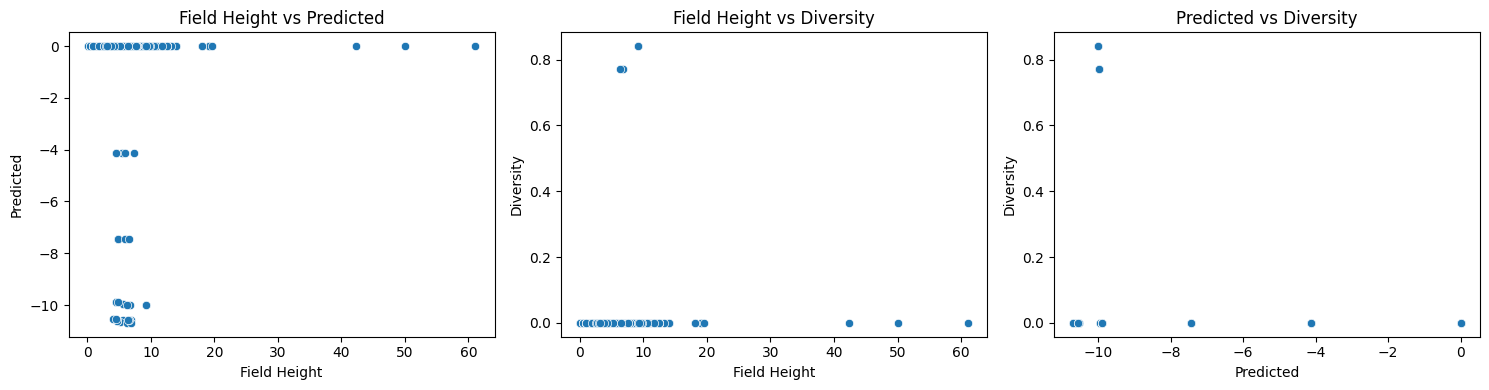

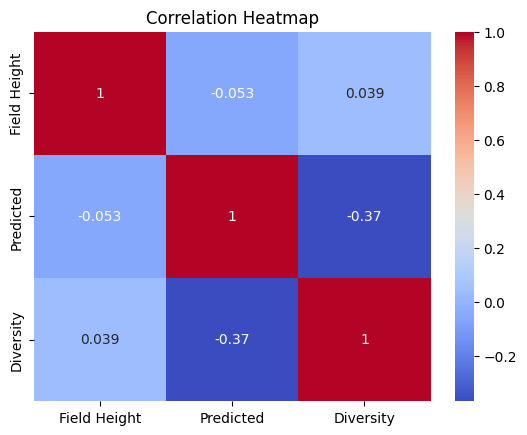

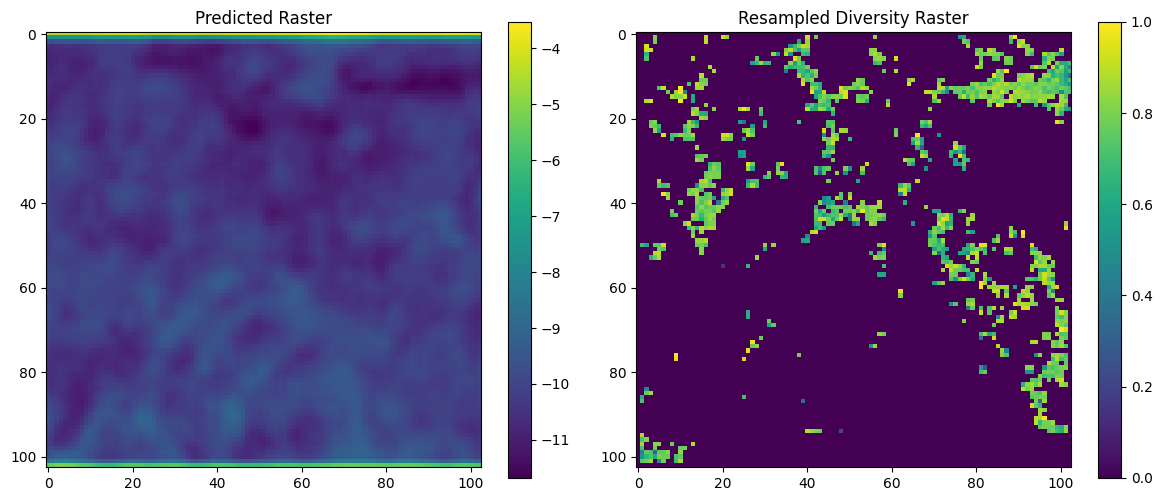

In [34]:
import pandas as pd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rasterio.warp import reproject, Resampling
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr
from pyproj import Transformer

# File paths
csv_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/NEON/veg.csv'
raster_pred_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/Reprojected_predictions/early_fusion_prediction_reproj.tif'
raster_div_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/PR_724000_1987000/foliage_height_diversity_lidr.tif'

# Load vegetation data
veg_df = pd.read_csv(csv_path)
coords = list(zip(veg_df['adjDecimalLongitude'], veg_df['adjDecimalLatitude']))

# Load predicted raster (target grid)
with rasterio.open(raster_pred_path) as src_pred:
    pred_data = src_pred.read(1, masked=True)
    pred_meta = src_pred.meta

# Load diversity raster (high-res, reproject to match predicted)
with rasterio.open(raster_div_path) as src_div:
    div_data = src_div.read(1, masked=True)
    resampled_div = np.empty_like(pred_data, dtype=np.float32)
    reproject(
        source=div_data,
        destination=resampled_div,
        src_transform=src_div.transform,
        src_crs=src_div.crs,
        dst_transform=src_pred.transform,
        dst_crs=src_pred.crs,
        resampling=Resampling.average
    )

# Transform coordinates if needed
if src_pred.crs.to_string() != 'EPSG:4326':
    transformer = Transformer.from_crs('EPSG:4326', src_pred.crs, always_xy=True)
    coords_transformed = [transformer.transform(x, y) for x, y in coords]
else:
    coords_transformed = coords

# Sample rasters
with rasterio.open(raster_pred_path) as src_pred, rasterio.io.MemoryFile() as memfile:
    div_profile = src_pred.profile.copy()
    div_profile.update(dtype='float32')
    with memfile.open(**div_profile) as dataset:
        dataset.write(resampled_div, 1)
        pred_vals = np.array([val[0] for val in src_pred.sample(coords_transformed)])
        div_vals = np.array([val[0] for val in dataset.sample(coords_transformed)])

# Add to dataframe
veg_df['predicted'] = pred_vals
veg_df['diversity'] = div_vals

# Clean data
veg_df_clean = veg_df.dropna(subset=['predicted', 'diversity', 'height'])
field_height = veg_df_clean['height'].values
predicted = veg_df_clean['predicted'].values
diversity = veg_df_clean['diversity'].values

# Compute statistics
def compute_stats(x, y):
    pearson_corr, _ = pearsonr(x, y)
    spearman_corr, _ = spearmanr(x, y)
    rmse = np.sqrt(mean_squared_error(x, y))
    mae = mean_absolute_error(x, y)
    return {
        'Pearson': pearson_corr,
        'Spearman': spearman_corr,
        'RMSE': rmse,
        'MAE': mae
    }

stats_pred = compute_stats(field_height, predicted)
stats_div = compute_stats(field_height, diversity)
stats_pred_div = compute_stats(predicted, diversity)

# Display statistics
print("--- Field Height vs Predicted ---")
print(stats_pred)
print("--- Field Height vs Diversity ---")
print(stats_div)
print("--- Predicted vs Diversity ---")
print(stats_pred_div)

# Plot scatter comparisons
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
sns.scatterplot(x=field_height, y=predicted)
plt.xlabel('Field Height'); plt.ylabel('Predicted')
plt.title('Field Height vs Predicted')

plt.subplot(1, 3, 2)
sns.scatterplot(x=field_height, y=diversity)
plt.xlabel('Field Height'); plt.ylabel('Diversity')
plt.title('Field Height vs Diversity')

plt.subplot(1, 3, 3)
sns.scatterplot(x=predicted, y=diversity)
plt.xlabel('Predicted'); plt.ylabel('Diversity')
plt.title('Predicted vs Diversity')

plt.tight_layout()
plt.show()

# Correlation heatmap
stat_matrix = pd.DataFrame({
    'Field Height': field_height,
    'Predicted': predicted,
    'Diversity': diversity
})
corr = stat_matrix.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Visualize rasters side by side
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(pred_data, cmap='viridis')
plt.title('Predicted Raster')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(resampled_div, cmap='viridis')
plt.title('Resampled Diversity Raster')
plt.colorbar()

plt.tight_layout()
plt.show()
